<a href="https://colab.research.google.com/github/trang1981/ELAPS/blob/main/Notebooks/VIB_Dataprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOAD DỮ LIỆU

In [ ]:
import pandas as pd

# =========================
# LOAD CSV FILES
# =========================
customer = pd.read_csv("1.Data_Customer.csv")
transaction = pd.read_csv("2.Data_MyVIB_Transaction.csv")
activity = pd.read_csv("3.Data_MyVIB_Activity.csv")
deposit = pd.read_csv("4.Data_Deposit.csv")

# =========================
# LOAD EXCEL FILES
# =========================
lending = pd.read_excel("5.Data_Lending.xlsx")
card = pd.read_excel("6.Data_Card.xlsx")

# =========================
# CHECK SHAPE
# =========================
print("Customer:", customer.shape)
print("Transaction:", transaction.shape)
print("Activity:", activity.shape)
print("Deposit:", deposit.shape)
print("Lending:", lending.shape)
print("Card:", card.shape)

/tmp/ipykernel_2170/2524999982.py:6: DtypeWarning: Columns (5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  customer = pd.read_csv("1.Data_Customer.csv")
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


Customer: (290223, 9)
Transaction: (429137, 8)
Activity: (432325, 6)
Deposit: (541542, 6)
Lending: (576431, 4)
Card: (871589, 3)


XỬ LÝ FILE TARGET

In [ ]:
import pandas as pd
import numpy as np

# =========================
# LOAD FILE CARD
# =========================
card = pd.read_excel("6.Data_Card.xlsx")

# Chuẩn hóa tên cột
card.columns = card.columns.str.strip().str.upper()

# =========================
# CHỌN CỘT CẦN DÙNG
# =========================
target = card[["CUSTOMER_NUMBER", "COUNT_CREDITCARD", "MONTH"]].copy()

# Chuyển kiểu dữ liệu
target["COUNT_CREDITCARD"] = pd.to_numeric(target["COUNT_CREDITCARD"], errors="coerce").fillna(0)
target["MONTH"] = pd.to_datetime(target["MONTH"], errors="coerce")

# =========================
# GOM THEO KHÁCH HÀNG
# - số thẻ: lấy max
# - có thẻ -> TARGET = 1
# - không có thẻ -> TARGET = 0
# - ngày: có thẻ lấy min, không có thẻ lấy max
# =========================
summary = target.groupby("CUSTOMER_NUMBER").agg(
    MAX_CARD=("COUNT_CREDITCARD", "max"),
    MIN_MONTH=("MONTH", "min"),
    MAX_MONTH=("MONTH", "max")
).reset_index()

summary["TARGET"] = (summary["MAX_CARD"] > 0).astype(int)

summary["TARGET_MONTH"] = np.where(
    summary["TARGET"] == 1,
    summary["MIN_MONTH"],
    summary["MAX_MONTH"]
)

# =========================
# GIỮ CỘT CẦN THIẾT
# =========================
target_final = summary[["CUSTOMER_NUMBER", "TARGET", "TARGET_MONTH"]]

# =========================
# SAVE FILE
# =========================
target_final.to_csv("target_processed.csv", index=False)

print(target_final.head())
print(target_final.shape)
print("Saved: target_processed.csv")

   CUSTOMER_NUMBER  TARGET TARGET_MONTH
0                0       0   2019-12-31
1                3       0   2019-12-31
2                8       1   2019-05-31
3                9       0   2019-12-31
4               13       0   2019-12-31
(150459, 3)
Saved: target_processed.csv


4️⃣ Nối CUSTOMER với TARGET

In [ ]:
import pandas as pd

# =========================
# LOAD FILES
# =========================
customer = pd.read_csv("1.Data_Customer.csv")
target = pd.read_csv("target_processed.csv")

# =========================
# CHUẨN HÓA TÊN CỘT
# =========================
customer.columns = customer.columns.str.strip().str.upper()
target.columns = target.columns.str.strip().str.upper()

# =========================
# CHUYỂN KIỂU DỮ LIỆU
# =========================
customer["CLIENT_CREATE_DATE"] = pd.to_datetime(customer["CLIENT_CREATE_DATE"], errors="coerce")
target["TARGET_MONTH"] = pd.to_datetime(target["TARGET_MONTH"], errors="coerce")

# =========================
# INNER JOIN
# GIỮ LẠI KHÁCH HÀNG CÓ TRONG FILE 6
# =========================
df = customer.merge(
    target,
    on="CUSTOMER_NUMBER",
    how="inner"
)

print("Before filtering:", df.shape)

# =========================
# XÓA KHÁCH HÀNG CÓ NGÀY MỞ THẺ
# TRƯỚC NGÀY MỞ TÀI KHOẢN
# =========================
df = df[df["TARGET_MONTH"] >= df["CLIENT_CREATE_DATE"]]

print("After filtering:", df.shape)

# =========================
# SAVE FILE
# =========================
df.to_csv("step2_customer_target_filtered.csv", index=False)

print("Saved: step2_customer_target_filtered.csv")
print(df.head())

/tmp/ipykernel_2170/323713265.py:6: DtypeWarning: Columns (5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  customer = pd.read_csv("1.Data_Customer.csv")


Before filtering: (150459, 11)
After filtering: (150408, 11)
Saved: step2_customer_target_filtered.csv
   CUSTOMER_NUMBER CLIENT_SEX CLIENT_CREATE_DATE        DATE_OF_BIRTH  \
0           639362          M         2019-04-23  1996-01-01 00:00:00   
1           452440          M         2019-01-11  1999-10-10 00:00:00   
2           326290          F         2019-05-27  1996-06-29 00:00:00   
3            20802          M         2019-11-12  1992-08-07 00:00:00   
4           106192          M         2019-04-18  1997-09-25 00:00:00   

  STAFF_VIB IB_REGISTER_DATE EB_REGISTER_CHANNEL SMS VERIFY_METHOD  TARGET  \
0         N       2019-04-23              BRANCH   Y           SMS       0   
1         N       2019-01-11              BRANCH   Y     SMART_OTP       0   
2         N       2019-05-27              BRANCH   Y           SMS       0   
3         N       2019-11-12              BRANCH   Y     SMART_OTP       0   
4         N       2019-04-18              BRANCH   Y           SMS  

5️⃣ Loại khách mở thẻ trước khi mở tài khoản

In [ ]:
import pandas as pd

# =========================
# LOAD FILES
# =========================
customer = pd.read_csv("1.Data_Customer.csv")
target = pd.read_csv("target_processed.csv")

# =========================
# CHUẨN HÓA TÊN CỘT
# =========================
customer.columns = customer.columns.str.strip().str.upper()
target.columns = target.columns.str.strip().str.upper()

# =========================
# CHUYỂN KIỂU DỮ LIỆU
# =========================
customer["CLIENT_CREATE_DATE"] = pd.to_datetime(customer["CLIENT_CREATE_DATE"], errors="coerce")
target["TARGET_MONTH"] = pd.to_datetime(target["TARGET_MONTH"], errors="coerce")

# =========================
# INNER JOIN
# GIỮ LẠI KHÁCH HÀNG CÓ TRONG FILE 6
# =========================
df = customer.merge(
    target,
    on="CUSTOMER_NUMBER",
    how="inner"
)

print("Before filtering:", df.shape)

# =========================
# XÓA KHÁCH HÀNG CÓ NGÀY MỞ THẺ
# TRƯỚC NGÀY MỞ TÀI KHOẢN
# =========================
df = df[df["TARGET_MONTH"] >= df["CLIENT_CREATE_DATE"]]

print("After filtering:", df.shape)

# =========================
# SAVE FILE
# =========================
df.to_csv("step2_customer_target_filtered.csv", index=False)

print("Saved: step2_customer_target_filtered.csv")
print(df.head())

/tmp/ipykernel_2170/323713265.py:6: DtypeWarning: Columns (5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  customer = pd.read_csv("1.Data_Customer.csv")


Before filtering: (150459, 11)
After filtering: (150408, 11)
Saved: step2_customer_target_filtered.csv
   CUSTOMER_NUMBER CLIENT_SEX CLIENT_CREATE_DATE        DATE_OF_BIRTH  \
0           639362          M         2019-04-23  1996-01-01 00:00:00   
1           452440          M         2019-01-11  1999-10-10 00:00:00   
2           326290          F         2019-05-27  1996-06-29 00:00:00   
3            20802          M         2019-11-12  1992-08-07 00:00:00   
4           106192          M         2019-04-18  1997-09-25 00:00:00   

  STAFF_VIB IB_REGISTER_DATE EB_REGISTER_CHANNEL SMS VERIFY_METHOD  TARGET  \
0         N       2019-04-23              BRANCH   Y           SMS       0   
1         N       2019-01-11              BRANCH   Y     SMART_OTP       0   
2         N       2019-05-27              BRANCH   Y           SMS       0   
3         N       2019-11-12              BRANCH   Y     SMART_OTP       0   
4         N       2019-04-18              BRANCH   Y           SMS  

6️⃣ Nối TRANSACTION

In [ ]:
import pandas as pd

# =========================
# LOAD FILES
# =========================
target = pd.read_csv("target_processed.csv")
trans = pd.read_csv("2.Data_MyVIB_Transaction.csv")

# =========================
# STANDARDIZE COLUMNS
# =========================
target.columns = target.columns.str.strip().str.upper()
trans.columns = trans.columns.str.strip().str.upper()

# =========================
# CONVERT DATE
# TARGET_MONTH là tên cột, nhưng chứa ngày đầy đủ
# =========================
target["TARGET_MONTH"] = pd.to_datetime(target["TARGET_MONTH"], errors="coerce")
trans["TRANS_DATE"] = pd.to_datetime(trans["TRANS_DATE"], errors="coerce")

# =========================
# CHECK DUPLICATE CUSTOMER
# =========================
print("Duplicate customers in target:", target["CUSTOMER_NUMBER"].duplicated().sum())

# =========================
# LEFT JOIN
# Giữ toàn bộ khách hàng trong target
# =========================
df = target.merge(
    trans,
    on="CUSTOMER_NUMBER",
    how="left"
)

print("Before filtering:", df.shape)
print("Customers before filtering:", df["CUSTOMER_NUMBER"].nunique())

# =========================
# GIỮ:
# - khách không có giao dịch
# - hoặc giao dịch trước ngày mở thẻ
# =========================
df = df[
    df["TRANS_DATE"].isna() |
    (
        df["TARGET_MONTH"].notna() &
        (df["TRANS_DATE"] < df["TARGET_MONTH"])
    )
]

print("After filtering:", df.shape)
print("Customers after filtering:", df["CUSTOMER_NUMBER"].nunique())

# =========================
# CHECK LEAKAGE
# =========================
leak = df[
    df["TRANS_DATE"].notna() &
    df["TARGET_MONTH"].notna() &
    (df["TRANS_DATE"] >= df["TARGET_MONTH"])
]

print("Remaining leakage rows:", leak.shape[0])

# =========================
# CHECK CUSTOMERS WITH NO TRANSACTION
# =========================
no_trans = df.groupby("CUSTOMER_NUMBER")["TRANS_DATE"].apply(lambda x: x.isna().all()).sum()
print("Customers with no transaction:", no_trans)

# =========================
# SAVE
# =========================
df.to_csv("step3_transaction_before_card_keep_all_customers.csv", index=False)

print("Saved: step3_transaction_before_card_keep_all_customers.csv")
print(df.head())

Duplicate customers in target: 0
Before filtering: (1404891, 10)
Customers before filtering: 150459
After filtering: (1171302, 10)
Customers after filtering: 144647
Remaining leakage rows: 0
Customers with no transaction: 104562
Saved: step3_transaction_before_card_keep_all_customers.csv
   CUSTOMER_NUMBER  TARGET TARGET_MONTH TRANS_LV1    TRANS_LV2 TRANS_DATE  \
0                0       0   2019-12-31  Transfer  Outside_VIB 2019-09-26   
1                0       0   2019-12-31  Transfer  Outside_VIB 2019-12-29   
2                0       0   2019-12-31  Transfer  Outside_VIB 2019-10-14   
3                0       0   2019-12-31  Transfer  Outside_VIB 2019-12-02   
4                0       0   2019-12-31  Transfer  Outside_VIB 2019-12-01   

  DAY_OF_WEEK  TRANS_HOUR  TRANS_NO  TRANS_AMOUNT  
0         Thu         9.0       1.0    99800000.0  
1         Sun        19.0       1.0    20000000.0  
2         Mon         8.0       1.0     2000000.0  
3         Mon        11.0       1.0    3

XỬ LÝ FILE CUSTOMMER

TẠO FEATURE CHO TRANSACTION

In [ ]:
import pandas as pd

df = pd.read_csv("step3_transaction_before_card_keep_all_customers.csv")
df.columns = df.columns.str.strip().str.upper()

df["TRANS_AMOUNT"] = pd.to_numeric(df["TRANS_AMOUNT"], errors="coerce").fillna(0)
df["TRANS_LV1"] = df["TRANS_LV1"].astype(str).str.strip().str.upper()
df["TRANS_LV2"] = df["TRANS_LV2"].astype(str).str.strip().str.upper()

def get_mode_value(series):
    s = series.dropna().astype(str).str.strip()
    if s.empty:
        return None
    return s.value_counts().idxmax()

feature = df.groupby("CUSTOMER_NUMBER").agg(
    TRANS_LV1_MODE=("TRANS_LV1", get_mode_value),
    TRANS_LV2_MODE=("TRANS_LV2", get_mode_value),
    TRANS_AMOUNT_MAX=("TRANS_AMOUNT", "max"),
    TRANS_AMOUNT_MEAN=("TRANS_AMOUNT", "mean"),
    TARGET=("TARGET", "max")
).reset_index()

# encode category -> code
feature["TRANS_LV1_MODE_CODE"] = feature["TRANS_LV1_MODE"].astype("category").cat.codes
feature["TRANS_LV2_MODE_CODE"] = feature["TRANS_LV2_MODE"].astype("category").cat.codes

feature.to_csv("feature_transaction_mode.csv", index=False)

print(feature.head())

   CUSTOMER_NUMBER TRANS_LV1_MODE TRANS_LV2_MODE  TRANS_AMOUNT_MAX  \
0                0       TRANSFER    OUTSIDE_VIB        99800000.0   
1                3            NAN            NAN               0.0   
2                8            NAN            NAN               0.0   
3                9          TOPUP         MOBILE         5000000.0   
4               13            NAN            NAN               0.0   

   TRANS_AMOUNT_MEAN  TARGET  TRANS_LV1_MODE_CODE  TRANS_LV2_MODE_CODE  
0       2.498190e+07       0                    3                   10  
1       0.000000e+00       0                    0                    9  
2       0.000000e+00       1                    0                    9  
3       1.949163e+06       0                    2                    8  
4       0.000000e+00       0                    0                    9  


Activity → nối với TARGET

In [ ]:
import pandas as pd

# =========================
# LOAD FILES
# =========================
target = pd.read_csv("target_processed.csv")
activity = pd.read_csv("3.Data_MyVIB_Activity.csv")

# =========================
# STANDARDIZE COLUMNS
# =========================
target.columns = target.columns.str.strip().str.upper()
activity.columns = activity.columns.str.strip().str.upper()

# =========================
# CONVERT DATE
# TARGET_MONTH là tên cột nhưng chứa ngày đầy đủ
# =========================
target["TARGET_MONTH"] = pd.to_datetime(target["TARGET_MONTH"], errors="coerce")
activity["ACTIVITY_DATE"] = pd.to_datetime(activity["ACTIVITY_DATE"], errors="coerce")

# =========================
# CHECK DUPLICATE CUSTOMER IN TARGET
# =========================
print("Duplicate customers in target:", target["CUSTOMER_NUMBER"].duplicated().sum())

# =========================
# LEFT JOIN
# Giữ toàn bộ khách hàng trong target
# =========================
df = target.merge(
    activity,
    on="CUSTOMER_NUMBER",
    how="left"
)

print("Before filtering:", df.shape)
print("Customers before filtering:", df["CUSTOMER_NUMBER"].nunique())

# =========================
# GIỮ:
# - khách không có hoạt động
# - hoặc hoạt động trước ngày mở thẻ
# =========================
df = df[
    df["ACTIVITY_DATE"].isna() |
    (
        df["TARGET_MONTH"].notna() &
        (df["ACTIVITY_DATE"] < df["TARGET_MONTH"])
    )
]

print("After filtering:", df.shape)
print("Customers after filtering:", df["CUSTOMER_NUMBER"].nunique())

# =========================
# CHECK LEAKAGE
# =========================
leak = df[
    df["ACTIVITY_DATE"].notna() &
    df["TARGET_MONTH"].notna() &
    (df["ACTIVITY_DATE"] >= df["TARGET_MONTH"])
]

print("Remaining leakage rows:", leak.shape[0])

# =========================
# CHECK CUSTOMERS WITH NO ACTIVITY
# =========================
no_activity = df.groupby("CUSTOMER_NUMBER")["ACTIVITY_DATE"].apply(lambda x: x.isna().all()).sum()
print("Customers with no activity:", no_activity)

# =========================
# SAVE
# =========================
df.to_csv("step4_activity_before_card_keep_all_customers.csv", index=False)

print("Saved: step4_activity_before_card_keep_all_customers.csv")
print(df.head())

Duplicate customers in target: 0
Before filtering: (14453051, 8)
Customers before filtering: 150459
After filtering: (11316579, 8)
Customers after filtering: 146307
Remaining leakage rows: 0
Customers with no activity: 87802
Saved: step4_activity_before_card_keep_all_customers.csv
   CUSTOMER_NUMBER  TARGET TARGET_MONTH ACTIVITY_DATE DAY_OF_WEEK  \
0                0       0   2019-12-31    2019-09-26         Thu   
1                0       0   2019-12-31    2019-10-03         Thu   
2                0       0   2019-12-31    2019-10-14         Mon   
3                0       0   2019-12-31    2019-11-29         Fri   
4                0       0   2019-12-31    2019-11-29         Fri   

   ACTIVITY_HOUR  ACTIVITY_NO          ACTIVITY_NAME  
0            9.0          3.0  MB_INTEREST_RATE_VIEW  
1           12.0          6.0  MB_INTEREST_RATE_VIEW  
2            8.0          2.0  MB_INTEREST_RATE_VIEW  
3           14.0          4.0  MB_INTEREST_RATE_VIEW  
4           19.0          6.

TẠO FEATURE CHO ACTIVITY

In [ ]:
import pandas as pd
import numpy as np

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("step4_activity_before_card_keep_all_customers.csv")

# =========================
# STANDARDIZE
# =========================
df.columns = df.columns.str.strip().str.upper()

df["ACTIVITY_DATE"] = pd.to_datetime(df["ACTIVITY_DATE"], errors="coerce")
df["ACTIVITY_NAME"] = df["ACTIVITY_NAME"].astype(str).str.upper()

# =========================
# FLAG
# =========================
df["IS_LOGIN"] = df["ACTIVITY_NAME"].str.contains("LOGIN").astype(int)
df["IS_INTEREST"] = df["ACTIVITY_NAME"].str.contains("INTEREST_RATE").astype(int)

# =========================
# GROUP BY CUSTOMER
# =========================
feat = df.groupby("CUSTOMER_NUMBER").agg(
    LOGIN_COUNT=("IS_LOGIN", "sum"),
    INTEREST_COUNT=("IS_INTEREST", "sum"),
    TOTAL_ACTIVITY=("ACTIVITY_NAME", "count"),
    ACTIVE_DAYS=("ACTIVITY_DATE", lambda x: x.dt.date.nunique())
).reset_index()

# =========================
# FEATURE CHÍNH
# =========================
feat["LOGIN_PER_ACTIVE_DAY"] = (
    feat["LOGIN_COUNT"] /
    feat["ACTIVE_DAYS"].replace(0, np.nan)
).fillna(0)

feat["INTEREST_RATE_RATIO"] = (
    feat["INTEREST_COUNT"] /
    feat["TOTAL_ACTIVITY"].replace(0, np.nan)
).fillna(0)

# =========================
# GIỮ 2 FEATURE + TARGET
# =========================
target = df[["CUSTOMER_NUMBER", "TARGET"]].drop_duplicates()

feature_final = feat.merge(target, on="CUSTOMER_NUMBER", how="left")

feature_final = feature_final[[
    "CUSTOMER_NUMBER",
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO",
    "TARGET"
]]

# =========================
# SAVE FILE
# =========================
feature_final.to_csv("feature_activity_2features.csv", index=False)

print("Saved: feature_activity_2features.csv")
print("Shape:", feature_final.shape)
print(feature_final.head())

Saved: feature_activity_2features.csv
Shape: (146307, 4)
   CUSTOMER_NUMBER  LOGIN_PER_ACTIVE_DAY  INTEREST_RATE_RATIO  TARGET
0                0              1.333333             0.126984       0
1                3              1.071429             0.188406       0
2                8              0.000000             0.000000       1
3                9              1.205882             0.201058       0
4               13              1.500000             0.153846       0


XỬ LÝ DEPOSITE

In [ ]:
import pandas as pd

# =========================
# LOAD FILES
# =========================
target = pd.read_csv("target_processed.csv")
deposit = pd.read_csv("4.Data_Deposit.csv")

# =========================
# STANDARDIZE COLUMNS
# =========================
target.columns = target.columns.str.strip().str.upper()
deposit.columns = deposit.columns.str.strip().str.upper()

# =========================
# CONVERT DATE
# TARGET_MONTH là ngày mở thẻ
# MONTH là mốc dữ liệu deposit
# =========================
target["TARGET_MONTH"] = pd.to_datetime(target["TARGET_MONTH"], errors="coerce")
deposit["MONTH"] = pd.to_datetime(deposit["MONTH"], errors="coerce")

# =========================
# LEFT JOIN
# GIỮ TOÀN BỘ KHÁCH HÀNG
# =========================
df = target.merge(
    deposit,
    on="CUSTOMER_NUMBER",
    how="left"
)

print("Before filtering:", df.shape)
print("Customers before filtering:", df["CUSTOMER_NUMBER"].nunique())

# =========================
# GIỮ:
# - khách không có deposit
# - hoặc dữ liệu deposit trước ngày mở thẻ
# =========================
df = df[
    df["MONTH"].isna() |
    (
        df["TARGET_MONTH"].notna() &
        (df["MONTH"] < df["TARGET_MONTH"])
    )
]

print("After filtering:", df.shape)
print("Customers after filtering:", df["CUSTOMER_NUMBER"].nunique())

# =========================
# CHECK LEAKAGE
# =========================
leak = df[
    df["MONTH"].notna() &
    df["TARGET_MONTH"].notna() &
    (df["MONTH"] >= df["TARGET_MONTH"])
]

print("Remaining leakage rows:", leak.shape[0])

# =========================
# CHECK KHÁCH KHÔNG CÓ DEPOSIT
# =========================
no_deposit = df.groupby("CUSTOMER_NUMBER")["MONTH"].apply(lambda x: x.isna().all()).sum()
print("Customers with no deposit:", no_deposit)

# =========================
# SAVE
# =========================
df.to_csv("step5_deposit_before_card_keep_all_customers.csv", index=False)

print("Saved: step5_deposit_before_card_keep_all_customers.csv")
print(df.head())

Before filtering: (691470, 8)
Customers before filtering: 150459
After filtering: (500748, 8)
Customers after filtering: 130925
Remaining leakage rows: 0
Customers with no deposit: 34919
Saved: step5_deposit_before_card_keep_all_customers.csv
   CUSTOMER_NUMBER  TARGET TARGET_MONTH      MONTH  COUNT_CA_ACCT  \
0                0       0   2019-12-31 2019-09-30            1.0   
1                0       0   2019-12-31 2019-10-31            1.0   
2                0       0   2019-12-31 2019-11-30            1.0   
4                3       0   2019-12-31 2019-05-31            1.0   
5                3       0   2019-12-31 2019-06-30            1.0   

   AVG_CA_BALANCE  COUNT_TD_ACCT  AVG_TD_BALANCE  
0     57364833.33            0.0             0.0  
1       750812.90            0.0             0.0  
2      5280833.33            0.0             0.0  
4       265089.26            0.0             0.0  
5       689391.60            0.0             0.0  


TẠO FEATURE DEPOSITE

In [ ]:
import pandas as pd

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("step5_deposit_before_card_keep_all_customers.csv")

# =========================
# STANDARDIZE
# =========================
df.columns = df.columns.str.strip().str.upper()

df["MONTH"] = pd.to_datetime(df["MONTH"], errors="coerce")

# =========================
# SORT THEO THỜI GIAN
# =========================
df = df.sort_values(["CUSTOMER_NUMBER", "MONTH"])

# =========================
# LẤY SNAPSHOT GẦN NHẤT
# =========================
feat = df.groupby("CUSTOMER_NUMBER").tail(1).copy()

# =========================
# CHỌN 4 FEATURE
# =========================
feature_deposit = feat[[
    "CUSTOMER_NUMBER",
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE",
    "TARGET"
]]

# =========================
# FILL NA (KHÁCH KHÔNG CÓ DEPOSIT)
# =========================
feature_deposit = feature_deposit.fillna(0)

# =========================
# SAVE
# =========================
feature_deposit.to_csv("feature_deposit_4features.csv", index=False)

print("Saved: feature_deposit_4features.csv")
print("Shape:", feature_deposit.shape)
print(feature_deposit.head())

Saved: feature_deposit_4features.csv
Shape: (130925, 6)
    CUSTOMER_NUMBER  COUNT_CA_ACCT  AVG_CA_BALANCE  COUNT_TD_ACCT  \
2                 0            1.0      5280833.33            0.0   
9                 3            1.0       646748.67            0.0   
10                8            0.0            0.00            0.0   
12                9            1.0      5369682.93            0.0   
13               13            0.0            0.00            0.0   

    AVG_TD_BALANCE  TARGET  
2              0.0       0  
9              0.0       0  
10             0.0       1  
12             0.0       0  
13             0.0       0  


XỬ LÝ FILE CUSTOMER

In [ ]:
import pandas as pd
import os

# =========================
# LOAD DATA
# =========================
file_path = "step2_customer_target_filtered.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"{file_path} NOT FOUND")

df = pd.read_csv(file_path)

# =========================
# STANDARDIZE
# =========================
df.columns = df.columns.str.strip().str.upper()

# =========================
# CONVERT DATE
# =========================
df["DATE_OF_BIRTH"] = pd.to_datetime(df["DATE_OF_BIRTH"], errors="coerce")

# =========================
# TÍNH AGE
# =========================
reference_date = pd.to_datetime("2019-12-31")

df["AGE"] = (reference_date - df["DATE_OF_BIRTH"]).dt.days / 365.25

# xử lý lỗi
df.loc[df["AGE"] < 0, "AGE"] = None
df.loc[df["AGE"] > 100, "AGE"] = None

df["AGE"] = df["AGE"].fillna(df["AGE"].median()).astype(int)

# =========================
# ❗ XÓA DATE_OF_BIRTH
# =========================
df = df.drop(columns=["DATE_OF_BIRTH"])

# =========================
# SAVE
# =========================
df.to_csv("step2_customer_with_age.csv", index=False)

print("Saved: step2_customer_with_age.csv")
print(df.head())

/tmp/ipykernel_50306/2518785546.py:12: DtypeWarning: Columns (5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Saved: step2_customer_with_age.csv
   CUSTOMER_NUMBER CLIENT_SEX CLIENT_CREATE_DATE STAFF_VIB IB_REGISTER_DATE  \
0           639362          M         2019-04-23         N       2019-04-23   
1           452440          M         2019-01-11         N       2019-01-11   
2           326290          F         2019-05-27         N       2019-05-27   
3            20802          M         2019-11-12         N       2019-11-12   
4           106192          M         2019-04-18         N       2019-04-18   

  EB_REGISTER_CHANNEL SMS VERIFY_METHOD  TARGET TARGET_MONTH  AGE  
0              BRANCH   Y           SMS       0   2019-12-31   23  
1              BRANCH   Y     SMART_OTP       0   2019-12-31   20  
2              BRANCH   Y           SMS       0   2019-12-31   23  
3              BRANCH   Y     SMART_OTP       0   2019-12-31   27  
4              BRANCH   Y           SMS       0   2019-12-31   22  


LENDING → nối với TARGET

In [ ]:
import pandas as pd

# =========================
# LOAD FILES
# =========================
target = pd.read_csv("target_processed.csv")
lending = pd.read_excel("5.Data_Lending.xlsx")

# =========================
# STANDARDIZE COLUMNS
# =========================
target.columns = target.columns.str.strip().str.upper()
lending.columns = lending.columns.str.strip().str.upper()

# =========================
# CONVERT DATE
# =========================
target["TARGET_MONTH"] = pd.to_datetime(target["TARGET_MONTH"], errors="coerce")
lending["MONTH"] = pd.to_datetime(lending["MONTH"], errors="coerce")

# Nếu AVG_LOAN_AMOUNT đang có dấu phẩy ngăn cách hàng nghìn
lending["AVG_LOAN_AMOUNT"] = (
    lending["AVG_LOAN_AMOUNT"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
lending["AVG_LOAN_AMOUNT"] = pd.to_numeric(lending["AVG_LOAN_AMOUNT"], errors="coerce")

lending["COUNT_OF_LOAN"] = pd.to_numeric(lending["COUNT_OF_LOAN"], errors="coerce")

# =========================
# LEFT JOIN
# GIỮ TOÀN BỘ KHÁCH HÀNG
# =========================
df = target.merge(
    lending,
    on="CUSTOMER_NUMBER",
    how="left"
)

print("Before filtering:", df.shape)
print("Customers before filtering:", df["CUSTOMER_NUMBER"].nunique())

# =========================
# GIỮ:
# - khách không có loan
# - hoặc bản ghi lending trước ngày mở thẻ
# =========================
df = df[
    df["MONTH"].isna() |
    (
        df["TARGET_MONTH"].notna() &
        (df["MONTH"] < df["TARGET_MONTH"])
    )
]

print("After filtering:", df.shape)
print("Customers after filtering:", df["CUSTOMER_NUMBER"].nunique())

# =========================
# CHECK LEAKAGE
# =========================
leak = df[
    df["MONTH"].notna() &
    df["TARGET_MONTH"].notna() &
    (df["MONTH"] >= df["TARGET_MONTH"])
]

print("Remaining leakage rows:", leak.shape[0])

# =========================
# CHECK KHÁCH KHÔNG CÓ LOAN
# =========================
no_loan = df.groupby("CUSTOMER_NUMBER")["MONTH"].apply(lambda x: x.isna().all()).sum()
print("Customers with no loan:", no_loan)

# =========================
# SAVE
# =========================
df.to_csv("step6_lending_before_card_keep_all_customers.csv", index=False)

print("Saved: step6_lending_before_card_keep_all_customers.csv")
print(df.head())

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


Before filtering: (346921, 6)
Customers before filtering: 150459
After filtering: (158812, 6)
Customers after filtering: 118599
Remaining leakage rows: 0
Customers with no loan: 107248
Saved: step6_lending_before_card_keep_all_customers.csv
    CUSTOMER_NUMBER  TARGET TARGET_MONTH      MONTH  COUNT_OF_LOAN  \
0                 0       0   2019-12-31        NaT            NaN   
1                 3       0   2019-12-31        NaT            NaN   
9                 9       0   2019-12-31 2019-10-31            1.0   
10                9       0   2019-12-31 2019-11-30            1.0   
12               13       0   2019-12-31        NaT            NaN   

    AVG_LOAN_AMOUNT  
0               NaN  
1               NaN  
9      1.550000e+09  
10     1.541389e+09  
12              NaN  


In [ ]:
import pandas as pd

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("step6_lending_before_card_keep_all_customers.csv")

# =========================
# STANDARDIZE
# =========================
df.columns = df.columns.str.strip().str.upper()

# =========================
# CONVERT DATE
# =========================
df["MONTH"] = pd.to_datetime(df["MONTH"], errors="coerce")

# =========================
# CLEAN NUMBER
# =========================
df["AVG_LOAN_AMOUNT"] = (
    df["AVG_LOAN_AMOUNT"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
df["AVG_LOAN_AMOUNT"] = pd.to_numeric(df["AVG_LOAN_AMOUNT"], errors="coerce")

df["COUNT_OF_LOAN"] = pd.to_numeric(df["COUNT_OF_LOAN"], errors="coerce")

# =========================
# SORT + LẤY SNAPSHOT GẦN NHẤT
# =========================
df = df.sort_values(["CUSTOMER_NUMBER", "MONTH"])

feat = df.groupby("CUSTOMER_NUMBER").tail(1).copy()

# =========================
# TẠO FEATURE
# =========================
feat["TOTAL_LOAN_AMOUNT"] = (
    feat["COUNT_OF_LOAN"].fillna(0) *
    feat["AVG_LOAN_AMOUNT"].fillna(0)
)

# =========================
# FINAL FEATURE
# =========================
feature_lending = feat[[
    "CUSTOMER_NUMBER",
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT",
    "TARGET"
]].fillna(0)

# =========================
# SAVE
# =========================
feature_lending.to_csv("feature_lending.csv", index=False)

print("Saved: feature_lending.csv")
print(feature_lending.head())

Saved: feature_lending.csv
   CUSTOMER_NUMBER  COUNT_OF_LOAN  AVG_LOAN_AMOUNT  TOTAL_LOAN_AMOUNT  TARGET
0                0            0.0     0.000000e+00       0.000000e+00       0
1                3            0.0     0.000000e+00       0.000000e+00       0
3                9            1.0     1.541389e+09       1.541389e+09       0
4               13            0.0     0.000000e+00       0.000000e+00       0
5               15            0.0     0.000000e+00       0.000000e+00       0


In [ ]:
import pandas as pd
import os

# =========================
# 1. LOAD DATA
# =========================
files = {
    "activity": "feature_activity_2features.csv",
    "deposit": "feature_deposit_4features.csv",
    "lending": "feature_lending.csv",
    "transaction": "feature_transaction_mode.csv",
    "customer": "step2_customer_with_age.csv"
}

dfs = {}

for name, path in files.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} NOT FOUND")

    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.upper()

    if "CUSTOMER_NUMBER" not in df.columns:
        raise ValueError(f"{name} missing CUSTOMER_NUMBER")

    print(f"{name} shape:", df.shape)
    print(f"{name} duplicates:", df["CUSTOMER_NUMBER"].duplicated().sum())

    dfs[name] = df

# =========================
# 2. BASE TABLE (CUSTOMER)
# =========================
final_df = dfs["customer"]

# =========================
# 3. MERGE LẦN LƯỢT
# =========================
for name in ["activity", "transaction", "deposit", "lending"]:
    final_df = final_df.merge(
        dfs[name],
        on="CUSTOMER_NUMBER",
        how="left"
    )
    print(f"After merging {name}:", final_df.shape)

# =========================
# 4. HANDLE MISSING
# =========================
final_df = final_df.fillna(0)

# =========================
# 5. CHECK FINAL
# =========================
print("Final shape:", final_df.shape)
print("Unique customers:", final_df["CUSTOMER_NUMBER"].nunique())
print("Duplicated customers:", final_df["CUSTOMER_NUMBER"].duplicated().sum())

# =========================
# 6. SAVE
# =========================
final_df.to_csv("final_dataset.csv", index=False)

print("Saved: final_dataset.csv")

activity shape: (146307, 3)
activity duplicates: 0
deposit shape: (130925, 5)
deposit duplicates: 0
lending shape: (118599, 4)
lending duplicates: 0
transaction shape: (40085, 7)
transaction duplicates: 0
customer shape: (150408, 8)
customer duplicates: 0
After merging activity: (150408, 10)
After merging transaction: (150408, 16)


/tmp/ipykernel_50306/2772068518.py:21: DtypeWarning: Columns (2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


After merging deposit: (150408, 20)
After merging lending: (150408, 23)
Final shape: (150408, 23)
Unique customers: 150408
Duplicated customers: 0
Saved: final_dataset.csv


  XÓA CÁC BẢN GHI CÓ EB_REGISTER_CHANEL LÀ AUTO_JOB

In [ ]:
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv("final_dataset.csv", low_memory=False)

# Kiểm tra số lượng trước khi xóa
print("Số bản ghi ban đầu:", len(df))

# Xóa các bản ghi có EB_REGISTER_CHANNEL = AUTO_JOB
df = df[
    df["EB_REGISTER_CHANNEL"]
    .astype(str)
    .str.strip()
    .str.upper()
    != "AUTO-JOB"
]

# Kiểm tra sau khi xóa
print("Số bản ghi sau khi xóa:", len(df))

# Lưu file mới
df.to_csv("final_dataset_no_auto_job.csv", index=False)

print("Đã lưu file: final_dataset_no_auto_job.csv")

Số bản ghi ban đầu: 150408
Số bản ghi sau khi xóa: 127460
Đã lưu file: final_dataset_no_auto_job.csv


MÃ HÓA DỮ LIỆU

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# =========================
# LOAD DATA
# =========================
file_path = "final_dataset_no_auto_job.csv"
df = pd.read_csv(file_path, low_memory=False)

df.columns = df.columns.str.strip()

# =========================
# DEFINE COLUMNS
# =========================
target_col = "COUNT_CREDITCARD"
id_col = "CUSTOMER_NUMBER"

# Tạo nhãn nhị phân
y = (df[target_col] > 0).astype(int)

# Loại bỏ ID và target khỏi đặc trưng đầu vào
X = df.drop(columns=[id_col, target_col])

# =========================
# DETECT COLUMN TYPES
# =========================
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Số biến đầu vào trước mã hóa:", X.shape[1])
print("Số biến số:", len(numeric_cols))
print("Số biến phân loại:", len(categorical_cols))

print("\nCác biến phân loại:")
print(categorical_cols)

# =========================
# PREPROCESSING
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ],
    remainder="drop"
)

X_processed = preprocessor.fit_transform(X)

# =========================
# GET FEATURE NAMES
# =========================
encoded_cat_cols = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)

final_feature_names = numeric_cols + encoded_cat_cols.tolist()

# =========================
# CREATE FINAL DATAFRAME
# =========================
X_processed_df = pd.DataFrame(X_processed, columns=final_feature_names)

# Thêm lại CUSTOMER_NUMBER để định danh nếu cần
X_processed_df.insert(0, id_col, df[id_col].values)

# Thêm target cuối file
X_processed_df[target_col] = y.values

# =========================
# EXPORT FILE
# =========================
output_file = "final_dataset_encoded_scaled.csv"
X_processed_df.to_csv(output_file, index=False, encoding="utf-8-sig")

print("\nXuất file thành công:", output_file)
print("Kích thước file sau mã hóa:", X_processed_df.shape)
print("Số đặc trưng đầu vào sau mã hóa:", len(final_feature_names))

# Kiểm tra cột phân loại thô còn hay không
raw_cat_remaining = [col for col in categorical_cols if col in X_processed_df.columns]

print("\nCột phân loại thô còn lại sau mã hóa:")
print(raw_cat_remaining)

if len(raw_cat_remaining) == 0:
    print("Kết luận: Các cột phân loại thô đã được loại bỏ sau khi mã hóa.")
else:
    print("Kết luận: Vẫn còn cột phân loại thô.")

Số biến đầu vào trước mã hóa: 20
Số biến số: 14
Số biến phân loại: 6

Các biến phân loại:
['CLIENT_SEX', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'TRANS_LV1_MODE', 'TRANS_LV2_MODE']

Xuất file thành công: final_dataset_encoded_scaled.csv
Kích thước file sau mã hóa: (127460, 49)
Số đặc trưng đầu vào sau mã hóa: 47

Cột phân loại thô còn lại sau mã hóa:
[]
Kết luận: Các cột phân loại thô đã được loại bỏ sau khi mã hóa.


XỬ LÝ, THỐNG KÊ FILE DATA CARD

In [ ]:
import pandas as pd

# Đọc dữ liệu
df = pd.read_excel("6.Data_Card.xlsx", sheet_name="in")

# Chuẩn hóa tên cột
df.columns = df.columns.str.strip()

# Đảm bảo MONTH là dạng ngày
df["MONTH"] = pd.to_datetime(df["MONTH"])

def select_customer_record(g):
    max_card = g["COUNT_CREDITCARD"].max()

    if max_card == 0:
        # Nếu chưa có thẻ: lấy ngày lớn nhất
        selected_date = g["MONTH"].max()
    else:
        # Nếu có thẻ: lấy ngày đầu tiên bắt đầu có thẻ
        selected_date = g.loc[g["COUNT_CREDITCARD"] > 0, "MONTH"].min()

    return pd.Series({
        "COUNT_CREDITCARD": max_card,
        "CARD_EVENT_DATE": selected_date
    })

# Nhóm theo khách hàng
result = (
    df.groupby("CUSTOMER_NUMBER", as_index=False)
      .apply(select_customer_record)
      .reset_index(drop=True)
)

# Xuất file kết quả
result.to_excel("customer_card_summary.xlsx", index=False)

print(result.head())
print("Đã tạo file: customer_card_summary.xlsx")

/tmp/ipykernel_2737/4184546822.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(select_customer_record)


   CUSTOMER_NUMBER  COUNT_CREDITCARD CARD_EVENT_DATE
0                0                 0      2019-12-31
1                3                 0      2019-12-31
2                8                 1      2019-05-31
3                9                 0      2019-12-31
4               13                 0      2019-12-31
Đã tạo file: customer_card_summary.xlsx


TRỰC QUAN HÓA SỐ LƯƠNG KHÁCH MỞ THẺ THEO THỜI GIAN

/tmp/ipykernel_2737/2792443899.py:8: DtypeWarning: Columns (5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  customer = pd.read_csv("1.Data_Customer.csv", encoding="utf-8-sig")
/tmp/ipykernel_2737/2792443899.py:9: DtypeWarning: Columns (2,3,4,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  final_df = pd.read_csv("final_dataset_no_auto_job.csv", encoding="utf-8-sig")
/tmp/ipykernel_2737/2792443899.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(select_card_date)
/tmp/ipykernel_2737/2792443899.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. P

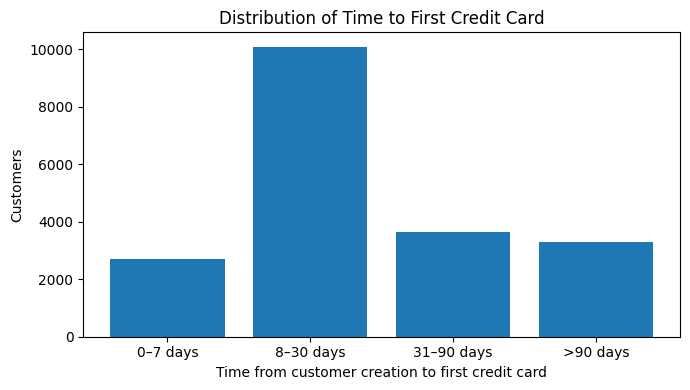

CARD_TIME_GROUP
0–7 days       2709
8–30 days     10088
31–90 days     3636
>90 days       3281
dtype: int64
Số khách hàng trong final dataset: 127460
Số khách hàng có thẻ dùng để vẽ biểu đồ: 19714


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. ĐỌC FILE
# =========================
card = pd.read_excel("6.Data_Card.xlsx", sheet_name="in")
customer = pd.read_csv("1.Data_Customer.csv", encoding="utf-8-sig")
final_df = pd.read_csv("final_dataset_no_auto_job.csv", encoding="utf-8-sig")

card.columns = card.columns.str.strip()
customer.columns = customer.columns.str.strip()
final_df.columns = final_df.columns.str.strip()

card["MONTH"] = pd.to_datetime(card["MONTH"])
customer["CLIENT_CREATE_DATE"] = pd.to_datetime(customer["CLIENT_CREATE_DATE"])

# =========================
# 2. CHỈ GIỮ KHÁCH HÀNG CÓ TRONG FILE FINAL
# =========================
valid_customers = final_df["CUSTOMER_NUMBER"].unique()

card = card[card["CUSTOMER_NUMBER"].isin(valid_customers)]
customer = customer[customer["CUSTOMER_NUMBER"].isin(valid_customers)]

# =========================
# 3. NHÓM FILE CARD THEO KHÁCH HÀNG
# =========================
def select_card_date(g):
    max_card = g["COUNT_CREDITCARD"].max()

    if max_card == 0:
        event_date = g["MONTH"].max()
    else:
        event_date = g.loc[g["COUNT_CREDITCARD"] > 0, "MONTH"].min()

    return pd.Series({
        "COUNT_CREDITCARD_MAX": max_card,
        "CARD_EVENT_DATE": event_date
    })

card_summary = (
    card.groupby("CUSTOMER_NUMBER")
        .apply(select_card_date)
        .reset_index()
)

# =========================
# 4. KẾT NỐI VỚI FILE CUSTOMER
# =========================
df = customer.merge(card_summary, on="CUSTOMER_NUMBER", how="inner")

# =========================
# 5. TÍNH SỐ NGÀY TỪ NGÀY KẾT NỐI ĐẾN NGÀY MỞ THẺ
# =========================
df["DAYS_TO_CARD"] = (
    df["CARD_EVENT_DATE"] - df["CLIENT_CREATE_DATE"]
).dt.days

# Chỉ thống kê khách hàng có thẻ
df_card = df[df["COUNT_CREDITCARD_MAX"] > 0].copy()

# =========================
# 6. CHIA NHÓM NGÀY
# =========================
bins = [-1, 7, 30, 90, float("inf")]
labels = ["0–7 days", "8–30 days", "31–90 days", ">90 days"]

df_card["CARD_TIME_GROUP"] = pd.cut(
    df_card["DAYS_TO_CARD"],
    bins=bins,
    labels=labels
)

chart_data = (
    df_card.groupby("CARD_TIME_GROUP")
           .size()
           .reindex(labels, fill_value=0)
)

# =========================
# 7. VẼ BIỂU ĐỒ
# =========================
plt.figure(figsize=(7, 4))

plt.bar(
    chart_data.index.astype(str),
    chart_data.values
)

plt.ylabel("Customers")
plt.xlabel("Time from customer creation to first credit card")
plt.title("Distribution of Time to First Credit Card")

plt.tight_layout()
plt.savefig("card_time_distribution_final_customers.png", dpi=300)
plt.show()

# =========================
# 8. XUẤT FILE
# =========================
df.to_excel("customer_card_filtered_final.xlsx", index=False)
chart_data.to_excel("card_time_group_summary_final.xlsx")

print(chart_data)
print("Số khách hàng trong final dataset:", len(valid_customers))
print("Số khách hàng có thẻ dùng để vẽ biểu đồ:", len(df_card))

TẠO BẢNG THỐNG KÊ THEO SỐ THẺ CA

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1. ĐỌC FILE
# =========================
card = pd.read_excel("6.Data_Card.xlsx", sheet_name="in")
customer = pd.read_csv("1.Data_Customer.csv", encoding="utf-8-sig")
final_df = pd.read_csv("final_dataset_no_auto_job.csv", encoding="utf-8-sig")

card.columns = card.columns.str.strip()
customer.columns = customer.columns.str.strip()
final_df.columns = final_df.columns.str.strip()

card["MONTH"] = pd.to_datetime(card["MONTH"])
customer["CLIENT_CREATE_DATE"] = pd.to_datetime(customer["CLIENT_CREATE_DATE"])

# =========================
# 2. CHỈ GIỮ KHÁCH HÀNG TRONG FINAL DATASET
# =========================
valid_customers = final_df["CUSTOMER_NUMBER"].unique()

card = card[card["CUSTOMER_NUMBER"].isin(valid_customers)]
customer = customer[customer["CUSTOMER_NUMBER"].isin(valid_customers)]
final_df = final_df[final_df["CUSTOMER_NUMBER"].isin(valid_customers)]

# =========================
# 3. TẠO EVENT DATE MỞ THẺ
# =========================
def select_card_date(g):
    max_card = g["COUNT_CREDITCARD"].max()

    if max_card == 0:
        event_date = g["MONTH"].max()
    else:
        event_date = g.loc[g["COUNT_CREDITCARD"] > 0, "MONTH"].min()

    return pd.Series({
        "COUNT_CREDITCARD_MAX": max_card,
        "CARD_EVENT_DATE": event_date
    })

card_summary = (
    card.groupby("CUSTOMER_NUMBER")
        .apply(select_card_date)
        .reset_index()
)

# =========================
# 4. GHÉP CUSTOMER + CARD + FINAL DATASET
# =========================
df = (
    final_df
    .merge(customer[["CUSTOMER_NUMBER", "CLIENT_CREATE_DATE"]],
           on="CUSTOMER_NUMBER", how="left")
    .merge(card_summary,
           on="CUSTOMER_NUMBER", how="left")
)

# =========================
# 5. TÍNH SỐ NGÀY MỞ THẺ
# =========================
df["DAYS_TO_CARD"] = (
    df["CARD_EVENT_DATE"] - df["CLIENT_CREATE_DATE"]
).dt.days

# Chỉ xét khách hàng có thẻ
df_card = df[df["COUNT_CREDITCARD_MAX"] > 0].copy()

# =========================
# 6. TẠO NHÓM CA
# =========================
df_card["CA_GROUP"] = np.where(
    df_card["COUNT_CA_ACCT"] == 0,
    "CA=0",
    "CA≥1"
)

# =========================
# 7. HÀM TÍNH THỐNG KÊ
# =========================
def calc_stats(g):
    return pd.Series({
        "Open ≤7 days": (g["DAYS_TO_CARD"] <= 7).mean(),
        "Open ≤30 days": (g["DAYS_TO_CARD"] <= 30).mean(),
        "Median days": g["DAYS_TO_CARD"].median(),
        "Loan account": (g["COUNT_OF_LOAN"] > 0).mean(),
        "TD account": (g["COUNT_TD_ACCT"] > 0).mean()
    })

summary = (
    df_card.groupby("CA_GROUP")
           .apply(calc_stats)
           .T
)

# Đảm bảo đúng thứ tự cột
summary = summary[["CA=0", "CA≥1"]]

# =========================
# 8. FORMAT CHO ĐẸP
# =========================
summary.loc["Open ≤7 days"] = summary.loc["Open ≤7 days"] * 100
summary.loc["Open ≤30 days"] = summary.loc["Open ≤30 days"] * 100
summary.loc["Loan account"] = summary.loc["Loan account"] * 100
summary.loc["TD account"] = summary.loc["TD account"] * 100

summary_formatted = summary.copy()

for row in ["Open ≤7 days", "Open ≤30 days", "Loan account", "TD account"]:
    summary_formatted.loc[row] = summary_formatted.loc[row].map(lambda x: f"{x:.1f}%")

summary_formatted.loc["Median days"] = summary.loc["Median days"].map(lambda x: f"{x:.0f}")

# =========================
# 9. XUẤT FILE
# =========================
summary_formatted.to_excel("CA_group_behavior_summary.xlsx")

print(summary_formatted)

/tmp/ipykernel_2737/3994134601.py:8: DtypeWarning: Columns (5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  customer = pd.read_csv("1.Data_Customer.csv", encoding="utf-8-sig")
/tmp/ipykernel_2737/3994134601.py:9: DtypeWarning: Columns (2,3,4,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  final_df = pd.read_csv("final_dataset_no_auto_job.csv", encoding="utf-8-sig")


CA_GROUP        CA=0   CA≥1
Open ≤7 days   16.8%   0.0%
Open ≤30 days  78.9%   1.4%
Median days       20     89
Loan account    0.7%  75.9%
TD account      1.5%  11.3%


/tmp/ipykernel_2737/3994134601.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(select_card_date)
/tmp/ipykernel_2737/3994134601.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calc_stats)
/tmp/ipykernel_2737/3994134601.py:111: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '16.8%' has dtype incompatible 

In [ ]:
import os

print(os.listdir("/content"))

if os.path.exists("/content/drive"):
    print("Inside /content/drive:", os.listdir("/content/drive"))

['.config', 'drive', 'sample_data']
Inside /content/drive: ['MyDrive']


In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive"))

True


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive")[:20])

['Santander_External_Validation_Results']


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/Santander_External_Validation_Results"):
    for f in files:
        print(os.path.join(root, f))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Kiểm tra thông tin dữ liệu file Santander Product Recommendation

In [ ]:

# ==============================================
# STEP 1. Mount Google Drive
# ==============================================

from google.colab import drive
drive.mount('/content/drive')

# ==============================================
# STEP 2. Tìm file train_ver2.csv
# ==============================================

import os

file_path = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "train_ver2.csv" in files:
        file_path = os.path.join(root, "train_ver2.csv")
        break

if file_path is None:
    raise FileNotFoundError("Không tìm thấy train_ver2.csv trong Google Drive!")

print("Đã tìm thấy file:")
print(file_path)

# ==============================================
# STEP 3. Chỉ giữ các cột cần thiết
# ==============================================

keep_columns = [
    "fecha_dato",
    "ncodpers",
    "ind_empleado",
    "pais_residencia",
    "sexo",
    "age",
    "fecha_alta",
    "ind_nuevo",
    "antiguedad",
    "indrel",
    "ult_fec_cli_1t",
    "indrel_1mes",
    "tiprel_1mes",
    "indresi",
    "indext",
    "conyuemp",
    "canal_entrada",
    "indfall",
    "tipodom",
    "cod_prov",
    "nomprov",
    "ind_actividad_cliente",
    "renta",
    "segmento",
    "ind_tjcr_fin_ult1"
]

# ==============================================
# STEP 4. Đọc theo từng chunk
# ==============================================

import pandas as pd

output_file = "/content/drive/MyDrive/Santander_CreditCard.csv"

chunksize = 500000

first_chunk = True
total_rows = 0

for chunk in pd.read_csv(
    file_path,
    usecols=keep_columns,
    chunksize=chunksize,
    low_memory=False
):

    total_rows += len(chunk)

    chunk.to_csv(
        output_file,
        mode='w' if first_chunk else 'a',
        header=first_chunk,
        index=False
    )

    print(f"Đã xử lý {total_rows:,} dòng")

    first_chunk = False

print("="*60)
print("HOÀN THÀNH!")
print("File đã lưu tại:")
print(output_file)

# ==============================================
# STEP 5. Kiểm tra file mới
# ==============================================

df = pd.read_csv(output_file, nrows=5)

print(df.head())

print(df.columns.tolist())

print("Số cột:", len(df.columns))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã tìm thấy file:
/content/drive/MyDrive/train_ver2.csv
Đã xử lý 500,000 dòng
Đã xử lý 1,000,000 dòng
Đã xử lý 1,500,000 dòng
Đã xử lý 2,000,000 dòng
Đã xử lý 2,500,000 dòng
Đã xử lý 3,000,000 dòng
Đã xử lý 3,500,000 dòng
Đã xử lý 4,000,000 dòng
Đã xử lý 4,500,000 dòng
Đã xử lý 5,000,000 dòng
Đã xử lý 5,500,000 dòng
Đã xử lý 6,000,000 dòng
Đã xử lý 6,500,000 dòng
Đã xử lý 7,000,000 dòng
Đã xử lý 7,500,000 dòng
Đã xử lý 8,000,000 dòng
Đã xử lý 8,500,000 dòng
Đã xử lý 9,000,000 dòng
Đã xử lý 9,500,000 dòng
Đã xử lý 10,000,000 dòng
Đã xử lý 10,500,000 dòng
Đã xử lý 11,000,000 dòng
Đã xử lý 11,500,000 dòng
Đã xử lý 12,000,000 dòng
Đã xử lý 12,500,000 dòng
Đã xử lý 13,000,000 dòng
Đã xử lý 13,500,000 dòng
Đã xử lý 13,647,309 dòng
HOÀN THÀNH!
File đã lưu tại:
/content/drive/MyDrive/Santander_CreditCard.csv
   fecha_dato  ncodpers ind_empleado pais_residencia sexo  

XỬ LÝ LAKELAGE VÀ GỘP DỮ LIỆU

In [ ]:
# ==========================================================
# 1. Mount Google Drive
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

# ==========================================================
# 2. Tự động tìm file Santander_CreditCard.csv trong Drive
# ==========================================================

import os
import pandas as pd
import numpy as np

input_file = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "Santander_CreditCard.csv" in files:
        input_file = os.path.join(root, "Santander_CreditCard.csv")
        break

if input_file is None:
    raise FileNotFoundError("Không tìm thấy file Santander_CreditCard.csv trong Google Drive.")

print("Đang đọc file:")
print(input_file)

# ==========================================================
# 3. Đọc dữ liệu
# ==========================================================

df = pd.read_csv(input_file, low_memory=False)

print("Kích thước dữ liệu gốc:", df.shape)

# ==========================================================
# 4. Chuẩn hóa kiểu dữ liệu
# ==========================================================

df["fecha_dato"] = pd.to_datetime(df["fecha_dato"], errors="coerce")
df["fecha_alta"] = pd.to_datetime(df["fecha_alta"], errors="coerce")

df["ind_tjcr_fin_ult1"] = pd.to_numeric(
    df["ind_tjcr_fin_ult1"],
    errors="coerce"
).fillna(0).astype(int)

# Loại các dòng thiếu ngày quan trọng
df = df.dropna(subset=["fecha_dato", "fecha_alta"])

# ==========================================================
# 5. Chỉ giữ dữ liệu trong năm đầu tiên từ fecha_alta
# ==========================================================

df["end_observation"] = df["fecha_alta"] + pd.DateOffset(years=1)

df = df[
    (df["fecha_dato"] >= df["fecha_alta"]) &
    (df["fecha_dato"] < df["end_observation"])
].copy()

df = df.sort_values(["ncodpers", "fecha_dato"])

print("Sau khi giữ năm đầu tiên:", df.shape)

# ==========================================================
# 6. Hàm lấy giá trị đầu/cuối an toàn
# ==========================================================

def safe_last(g, col):
    if col in g.columns:
        s = g[col].dropna()
        return s.iloc[-1] if len(s) > 0 else np.nan
    return np.nan

def safe_first(g, col):
    if col in g.columns:
        s = g[col].dropna()
        return s.iloc[0] if len(s) > 0 else np.nan
    return np.nan

# ==========================================================
# 7. Xử lý từng khách hàng theo nguyên tắc leakage-aware
# ==========================================================

def process_customer(g):
    g = g.sort_values("fecha_dato").copy()

    # Nếu có mở thẻ trong cửa sổ quan sát
    has_card = (g["ind_tjcr_fin_ult1"] == 1).any()

    if has_card:
        event_date = g.loc[g["ind_tjcr_fin_ult1"] == 1, "fecha_dato"].min()

        # Chỉ giữ dữ liệu trước tháng mở thẻ
        g_before = g[g["fecha_dato"] < event_date].copy()

        # Nếu không có dữ liệu trước event thì loại khách hàng
        if g_before.empty:
            return None

        target = 1

    else:
        # Không mở thẻ: giữ toàn bộ năm đầu tiên
        g_before = g.copy()
        target = 0

    out = {}

    # ID
    out["ncodpers"] = safe_first(g_before, "ncodpers")

    # Không dùng fecha_dato làm feature, chỉ giữ để kiểm tra
    out["last_snapshot_date"] = g_before["fecha_dato"].max()
    out["fecha_alta"] = safe_first(g_before, "fecha_alta")

    # Lấy giá trị cuối trước event
    last_cols = [
        "ind_empleado",
        "pais_residencia",
        "sexo",
        "age",
        "ind_nuevo",
        "antiguedad",
        "indrel",
        "indrel_1mes",
        "tiprel_1mes",
        "indresi",
        "indext",
        "conyuemp",
        "indfall",
        "tipodom",
        "cod_prov",
        "nomprov",
        "ind_actividad_cliente",
        "renta",
        "segmento"
    ]

    for col in last_cols:
        out[col] = safe_last(g_before, col)

    # Lấy giá trị đầu
    out["canal_entrada"] = safe_first(g_before, "canal_entrada")

    # Không giữ ult_fec_cli_1t vì thiếu nhiều
    out["TARGET"] = target

    return pd.Series(out)

# ==========================================================
# 8. Gom về 1 dòng/khách hàng
# ==========================================================

customer_level = (
    df.groupby("ncodpers", group_keys=False)
      .apply(process_customer)
      .reset_index(drop=True)
)

customer_level = customer_level.dropna(how="all").copy()

# ==========================================================
# 9. Kiểm tra dữ liệu sau xử lý
# ==========================================================

print("Kích thước dữ liệu cuối:", customer_level.shape)
print("\nPhân bố TARGET:")
print(customer_level["TARGET"].value_counts())
print("\nTỷ lệ TARGET:")
print(customer_level["TARGET"].value_counts(normalize=True))

print("\nKiểm tra số khách hàng:")
print("Số dòng:", len(customer_level))
print("Số khách hàng duy nhất:", customer_level["ncodpers"].nunique())

# ==========================================================
# 10. Lưu kết quả vào Google Drive
# ==========================================================

output_file = "/content/drive/MyDrive/Santander_CreditCard_LeakageAware_CustomerLevel.csv"

customer_level.to_csv(output_file, index=False)

print("\nĐã lưu file:")
print(output_file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang đọc file:
/content/drive/MyDrive/Santander_CreditCard.csv
Kích thước dữ liệu gốc: (13647309, 25)
Sau khi giữ năm đầu tiên: (1865323, 26)


/tmp/ipykernel_6024/3145901736.py:159: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(process_customer)


Kích thước dữ liệu cuối: (255627, 24)

Phân bố TARGET:
TARGET
0.0    254036
1.0      1591
Name: count, dtype: int64

Tỷ lệ TARGET:
TARGET
0.0    0.993776
1.0    0.006224
Name: proportion, dtype: float64

Kiểm tra số khách hàng:
Số dòng: 255627
Số khách hàng duy nhất: 255627

Đã lưu file:
/content/drive/MyDrive/Santander_CreditCard_LeakageAware_CustomerLevel.csv


In [ ]:
# ==========================================================
# 0. Cài thư viện nếu cần
# ==========================================================

!pip install -q imbalanced-learn xgboost shap

# ==========================================================
# 1. Mount Google Drive và đọc dữ liệu
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np

file_path = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "Santander_CreditCard_LeakageAware_CustomerLevel.csv" in files:
        file_path = os.path.join(root, "Santander_CreditCard_LeakageAware_CustomerLevel.csv")
        break

if file_path is None:
    raise FileNotFoundError("Không tìm thấy file dữ liệu đã xử lý trong Google Drive.")

df = pd.read_csv(file_path, low_memory=False)

print("Loaded file:", file_path)
print("Shape:", df.shape)
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded file: /content/drive/MyDrive/Santander_CreditCard_LeakageAware_CustomerLevel.csv
Shape: (255627, 24)
   ncodpers last_snapshot_date  fecha_alta ind_empleado pais_residencia sexo  \
0   15891.0         2015-08-28  2015-07-28            N              ES    H   
1   16063.0         2016-05-28  2015-11-19            N              ES    H   
2   16203.0         2016-05-28  2015-12-23            N              ES    V   
3   16502.0         2016-05-28  2015-09-30            N              ES    H   
4   17457.0         2015-08-28  2014-09-16            N              ES    H   

   age  ind_nuevo  antiguedad  indrel  ... conyuemp indfall tipodom cod_prov  \
0   59        0.0         246    99.0  ...        N       N     1.0     28.0   
1   62        0.0         255     1.0  ...        N       N     1.0     28.0   
2   70        0.0         255     1.0  ...

In [ ]:
# ==========================================================
# 2. Preprocessing summary
# ==========================================================

summary = pd.DataFrame({
    "Item": [
        "Number of customer-level records",
        "Number of unique customers",
        "Number of features before encoding",
        "Positive cases",
        "Negative cases",
        "Positive rate",
        "Missing values"
    ],
    "Value": [
        len(df),
        df["ncodpers"].nunique(),
        df.drop(columns=["TARGET"]).shape[1],
        int((df["TARGET"] == 1).sum()),
        int((df["TARGET"] == 0).sum()),
        round(df["TARGET"].mean(), 4),
        int(df.isna().sum().sum())
    ]
})

print(summary)

                                 Item        Value
0    Number of customer-level records  255627.0000
1          Number of unique customers  255627.0000
2  Number of features before encoding      23.0000
3                      Positive cases    1591.0000
4                      Negative cases  254036.0000
5                       Positive rate       0.0062
6                      Missing values  406065.0000


In [ ]:
# ==========================================================
# 3. Chuẩn bị dữ liệu cho mô hình
# ==========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, accuracy_score, recall_score,
    precision_score, f1_score, classification_report
)
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

# Không dùng ID và các cột ngày làm feature
drop_cols = [
    "TARGET",
    "ncodpers",
    "fecha_alta",
    "last_snapshot_date"
]

drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df["TARGET"].astype(int)

# Tách numeric / categorical
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

# Chia train/test stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Impute numeric
num_imputer = SimpleImputer(strategy="median")
X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

# Impute categorical
cat_imputer = SimpleImputer(strategy="most_frequent")
X_train_cat_raw = pd.DataFrame(
    cat_imputer.fit_transform(X_train[cat_cols]),
    columns=cat_cols,
    index=X_train.index
)

X_test_cat_raw = pd.DataFrame(
    cat_imputer.transform(X_test[cat_cols]),
    columns=cat_cols,
    index=X_test.index
)

# Ordinal encoding
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train_cat = pd.DataFrame(
    encoder.fit_transform(X_train_cat_raw),
    columns=cat_cols,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    encoder.transform(X_test_cat_raw),
    columns=cat_cols,
    index=X_test.index
)

# Ghép lại
X_train_processed = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_processed = pd.concat([X_test_num, X_test_cat], axis=1)

print("Train shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)
print("Train target distribution:")
print(y_train.value_counts(normalize=True))

Numeric columns: ['age', 'ind_nuevo', 'antiguedad', 'indrel', 'tipodom', 'cod_prov', 'ind_actividad_cliente', 'renta']
Categorical columns: ['ind_empleado', 'pais_residencia', 'sexo', 'indrel_1mes', 'tiprel_1mes', 'indresi', 'indext', 'conyuemp', 'indfall', 'nomprov', 'segmento', 'canal_entrada']
Train shape: (204501, 20)
Test shape: (51126, 20)
Train target distribution:
TARGET
0    0.993775
1    0.006225
Name: proportion, dtype: float64


In [ ]:
# ==========================================================
# 4. Random Oversampling - ROS
# ==========================================================

ros = RandomOverSampler(random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train_processed,
    y_train
)

print("Before ROS:")
print(y_train.value_counts())

print("After ROS:")
print(pd.Series(y_train_ros).value_counts())

Before ROS:
TARGET
0    203228
1      1273
Name: count, dtype: int64
After ROS:
TARGET
0    203228
1    203228
Name: count, dtype: int64


In [ ]:
# ==========================================================
# 5. XGBoost + ROS
# ==========================================================

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_ros, y_train_ros)

y_prob = xgb.predict_proba(X_test_processed)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

result = pd.DataFrame({
    "Model": ["XGBoost + ROS"],
    "AUC": [auc],
    "Accuracy": [acc],
    "Recall": [recall],
    "Precision": [precision],
    "F1-score": [f1]
})

print(result)
print(classification_report(y_test, y_pred))

           Model       AUC  Accuracy    Recall  Precision  F1-score
0  XGBoost + ROS  0.965648  0.890252  0.918239   0.049685   0.09427
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     50808
           1       0.05      0.92      0.09       318

    accuracy                           0.89     51126
   macro avg       0.52      0.90      0.52     51126
weighted avg       0.99      0.89      0.94     51126



In [ ]:
# ==========================================================
# 6. Ranking Evaluation: Precision@K, Lift@K
# ==========================================================

ranking = pd.DataFrame({
    "y_true": y_test.values,
    "y_prob": y_prob
})

ranking = ranking.sort_values("y_prob", ascending=False).reset_index(drop=True)

base_rate = ranking["y_true"].mean()

def precision_at_k(df_rank, k_ratio):
    k = int(len(df_rank) * k_ratio)
    top_k = df_rank.iloc[:k]
    precision_k = top_k["y_true"].mean()
    captured = top_k["y_true"].sum()
    capture_rate = captured / df_rank["y_true"].sum()
    lift = precision_k / base_rate
    return precision_k, captured, capture_rate, lift

k_list = [0.10, 0.20, 0.30]

rank_results = []

for k in k_list:
    p_k, captured, capture_rate, lift = precision_at_k(ranking, k)
    rank_results.append({
        "Top K": f"Top {int(k*100)}%",
        "Precision@K": p_k,
        "Captured Positives": int(captured),
        "Capture Rate": capture_rate,
        "Lift@K": lift
    })

rank_table = pd.DataFrame(rank_results)

print(rank_table)

     Top K  Precision@K  Captured Positives  Capture Rate    Lift@K
0  Top 10%     0.055947                 286      0.899371  8.994766
1  Top 20%     0.030024                 307      0.965409  4.827138
2  Top 30%     0.020539                 315      0.990566  3.302059


In [ ]:
# ==========================================================
# 7. Decile Analysis
# ==========================================================

ranking["decile"] = pd.qcut(
    ranking.index + 1,
    q=10,
    labels=[f"D{i}" for i in range(1, 11)]
)

decile_table = ranking.groupby("decile").agg(
    Customers=("y_true", "count"),
    Positives=("y_true", "sum"),
    Adoption_Rate=("y_true", "mean"),
    Avg_Prob=("y_prob", "mean")
).reset_index()

decile_table["Lift"] = decile_table["Adoption_Rate"] / base_rate

print(decile_table)

  decile  Customers  Positives  Adoption_Rate  Avg_Prob      Lift
0     D1       5113        286       0.055936  0.729558  8.993007
1     D2       5113         21       0.004107  0.393771  0.660326
2     D3       5112          8       0.001565  0.156953  0.251602
3     D4       5113          3       0.000587  0.043824  0.094332
4     D5       5112          0       0.000000  0.016605  0.000000
5     D6       5113          0       0.000000  0.006279  0.000000
6     D7       5112          0       0.000000  0.002560  0.000000
7     D8       5113          0       0.000000  0.001640  0.000000
8     D9       5112          0       0.000000  0.001255  0.000000
9    D10       5113          0       0.000000  0.000848  0.000000


/tmp/ipykernel_2656/2719874600.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decile_table = ranking.groupby("decile").agg(


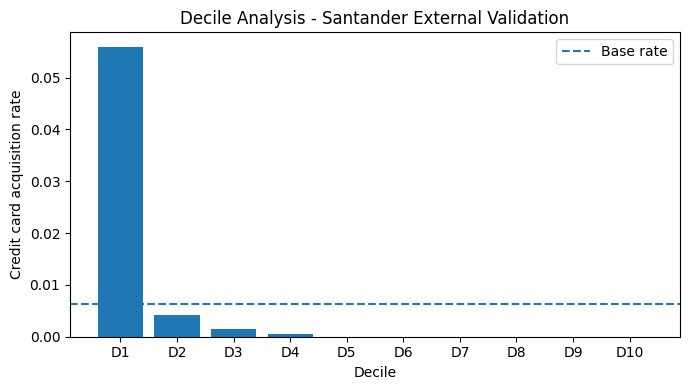

In [ ]:
# ==========================================================
# 8. Vẽ Decile Lift Chart
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(decile_table["decile"], decile_table["Adoption_Rate"])
plt.axhline(base_rate, linestyle="--", label="Base rate")
plt.xlabel("Decile")
plt.ylabel("Credit card acquisition rate")
plt.title("Decile Analysis - Santander External Validation")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# SHAP Summary Plot - Word/IEEE Friendly
# ==========================================================

import shap
import matplotlib.pyplot as plt
import os

# 1. Lấy mẫu SHAP
sample_size = min(1500, len(X_test_processed))

X_shap = X_test_processed.sample(
    n=sample_size,
    random_state=42
)

# 2. Tính SHAP values
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_shap)

# 3. Thiết lập font nhỏ theo chuẩn IEEE
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6
})

# 4. Vẽ SHAP summary plot
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=X_shap.columns,
    max_display=10,
    show=False
)

# 5. Ép kích thước hình sau khi SHAP tạo
fig = plt.gcf()
fig.set_size_inches(3.35, 2.55)

# 6. Chỉnh font các trục và colorbar
for ax in fig.axes:
    ax.tick_params(labelsize=6)

    if ax.get_xlabel():
        ax.set_xlabel(ax.get_xlabel(), fontsize=7)

    if ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel(), fontsize=7)

# 7. Căn lề vừa đủ, không quá tight
plt.subplots_adjust(
    left=0.34,
    right=0.88,
    top=0.96,
    bottom=0.18
)

# 8. Lưu hình vào Drive
output_dir = "/content/drive/MyDrive/Santander_External_Validation_Results"
os.makedirs(output_dir, exist_ok=True)

png_path = os.path.join(output_dir, "SHAP_Summary_Santander_Word_IEEE.png")
pdf_path = os.path.join(output_dir, "SHAP_Summary_Santander_Word_IEEE.pdf")

# PNG cho Word
plt.savefig(
    png_path,
    dpi=300
)

# PDF cho bản sắc nét hơn
plt.savefig(
    pdf_path
)

plt.close()

print("Đã lưu PNG:", png_path)
print("Đã lưu PDF:", pdf_path)

Đã lưu PNG: /content/drive/MyDrive/Santander_External_Validation_Results/SHAP_Summary_Santander_Word_IEEE.png
Đã lưu PDF: /content/drive/MyDrive/Santander_External_Validation_Results/SHAP_Summary_Santander_Word_IEEE.pdf


In [ ]:
from PIL import Image

img = Image.open("SHAP_Summary_IEEE.png")

print(img.size)

(1894, 1530)


In [ ]:
# ==========================================================
# 10. Bảng top SHAP features
# ==========================================================

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_ABS_SHAP": mean_abs_shap
}).sort_values("Mean_ABS_SHAP", ascending=False)

print(shap_importance.head(15))

                  Feature  Mean_ABS_SHAP
2              antiguedad       1.273452
0                     age       1.096640
6   ind_actividad_cliente       0.944706
12            tiprel_1mes       0.902871
19          canal_entrada       0.677921
7                   renta       0.370518
3                  indrel       0.196746
11            indrel_1mes       0.180282
18               segmento       0.137776
10                   sexo       0.134887
5                cod_prov       0.111649
1               ind_nuevo       0.107956
17                nomprov       0.105493
14                 indext       0.046617
16                indfall       0.006421


In [ ]:
# ==========================================================
# 11. Lưu kết quả ra Google Drive
# ==========================================================

output_dir = "/content/drive/MyDrive/Santander_External_Validation_Results"
os.makedirs(output_dir, exist_ok=True)

summary.to_csv(os.path.join(output_dir, "preprocessing_summary.csv"), index=False)
result.to_csv(os.path.join(output_dir, "xgboost_ros_results.csv"), index=False)
rank_table.to_csv(os.path.join(output_dir, "precision_lift_at_k.csv"), index=False)
decile_table.to_csv(os.path.join(output_dir, "decile_analysis.csv"), index=False)
shap_importance.to_csv(os.path.join(output_dir, "shap_importance.csv"), index=False)

print("Đã lưu toàn bộ kết quả tại:")
print(output_dir)

NameError: name 'rank_table' is not defined

In [ ]:
# ==========================================================
# Bootstrap Confidence Interval for AUC
# Santander External Validation
# ==========================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

# ----------------------------------------------------------
# y_test và y_prob phải có sẵn sau khi dự đoán
#
# y_test : nhãn thật
# y_prob : xác suất dự đoán của XGBoost
# ----------------------------------------------------------

# Nếu y_test là Series
y_true = np.array(y_test)

# Xác suất lớp positive
y_score = np.array(y_prob)

# ----------------------------------------------------------
# AUC gốc
# ----------------------------------------------------------

auc = roc_auc_score(y_true, y_score)

print(f"Original AUC = {auc:.6f}")

# ----------------------------------------------------------
# Bootstrap
# ----------------------------------------------------------

n_bootstrap = 1000
rng = np.random.RandomState(42)

bootstrap_scores = []

for i in range(n_bootstrap):

    indices = resample(
        np.arange(len(y_true)),
        replace=True,
        random_state=rng.randint(0, 1000000)
    )

    # Bootstrap sample
    y_boot = y_true[indices]
    score_boot = y_score[indices]

    # Nếu bootstrap chỉ có 1 class thì bỏ qua
    if len(np.unique(y_boot)) < 2:
        continue

    auc_boot = roc_auc_score(y_boot, score_boot)

    bootstrap_scores.append(auc_boot)

bootstrap_scores = np.array(bootstrap_scores)

# ----------------------------------------------------------
# Confidence Interval
# ----------------------------------------------------------

lower = np.percentile(bootstrap_scores, 2.5)
upper = np.percentile(bootstrap_scores, 97.5)

print("="*50)
print(f"AUC                : {auc:.6f}")
print(f"95% Bootstrap CI   : [{lower:.6f}, {upper:.6f}]")
print(f"Bootstrap samples  : {len(bootstrap_scores)}")
print("="*50)

# ----------------------------------------------------------
# Lưu kết quả
# ----------------------------------------------------------

result = pd.DataFrame({
    "Metric": ["AUC"],
    "Value": [auc],
    "CI Lower": [lower],
    "CI Upper": [upper],
    "Bootstrap": [len(bootstrap_scores)]
})

output_dir = "/content/drive/MyDrive/Santander_External_Validation_Results"

result.to_csv(
    f"{output_dir}/Bootstrap_AUC_CI.csv",
    index=False
)

print("Saved to Bootstrap_AUC_CI.csv")

Original AUC = 0.965648
AUC                : 0.965648
95% Bootstrap CI   : [0.958847, 0.971933]
Bootstrap samples  : 1000
Saved to Bootstrap_AUC_CI.csv


In [ ]:
print("xgb:", "xgb" in globals())
print("X_train_processed:", "X_train_processed" in globals())
print("X_test_processed:", "X_test_processed" in globals())
print("y_train:", "y_train" in globals())
print("y_test:", "y_test" in globals())

xgb: False
X_train_processed: True
X_test_processed: True
y_train: True
y_test: True


In [ ]:
# ==========================================================
# Santander External Validation
# AUC Bootstrap CI + Brier Score + Label Shuffling AUC
# ==========================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.utils import resample, shuffle
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

# ----------------------------------------------------------
# Cần có sẵn các biến:
# y_test, y_prob
# X_train_processed, X_test_processed, y_train
# ----------------------------------------------------------

# ==========================================================
# 1. AUC gốc + Brier Score
# ==========================================================

y_true = np.array(y_test)
y_score = np.array(y_prob)

auc = roc_auc_score(y_true, y_score)
brier = brier_score_loss(y_true, y_score)

print(f"Original AUC  = {auc:.6f}")
print(f"Brier Score   = {brier:.6f}")

# ==========================================================
# 2. Bootstrap 95% CI for AUC
# ==========================================================

n_bootstrap = 1000
rng = np.random.RandomState(42)

bootstrap_scores = []

for i in range(n_bootstrap):
    indices = resample(
        np.arange(len(y_true)),
        replace=True,
        random_state=rng.randint(0, 1000000)
    )

    y_boot = y_true[indices]
    score_boot = y_score[indices]

    if len(np.unique(y_boot)) < 2:
        continue

    auc_boot = roc_auc_score(y_boot, score_boot)
    bootstrap_scores.append(auc_boot)

bootstrap_scores = np.array(bootstrap_scores)

lower = np.percentile(bootstrap_scores, 2.5)
upper = np.percentile(bootstrap_scores, 97.5)

print("=" * 50)
print(f"AUC                : {auc:.6f}")
print(f"95% Bootstrap CI   : [{lower:.6f}, {upper:.6f}]")
print(f"Bootstrap samples  : {len(bootstrap_scores)}")
print("=" * 50)

# ==========================================================
# 3. Label Shuffling AUC
# ==========================================================

# Chỉ shuffle nhãn train, không shuffle test
y_train_shuffled = shuffle(
    pd.Series(y_train).reset_index(drop=True),
    random_state=42
)

X_train_shuffle = pd.DataFrame(X_train_processed).reset_index(drop=True)
X_test_shuffle = pd.DataFrame(X_test_processed).reset_index(drop=True)

ros_shuffle = RandomOverSampler(random_state=42)

X_train_shuffle_ros, y_train_shuffle_ros = ros_shuffle.fit_resample(
    X_train_shuffle,
    y_train_shuffled
)

xgb_shuffle = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_shuffle.fit(X_train_shuffle_ros, y_train_shuffle_ros)

y_prob_shuffle = xgb_shuffle.predict_proba(X_test_shuffle)[:, 1]

label_shuffle_auc = roc_auc_score(y_true, y_prob_shuffle)

print("=" * 50)
print(f"Label Shuffling AUC : {label_shuffle_auc:.6f}")
print("=" * 50)

# ==========================================================
# 4. Lưu kết quả
# ==========================================================

output_dir = "/content/drive/MyDrive/Santander_External_Validation_Results"
os.makedirs(output_dir, exist_ok=True)

result = pd.DataFrame({
    "Metric": [
        "AUC",
        "AUC_CI_Lower",
        "AUC_CI_Upper",
        "Brier_Score",
        "Label_Shuffling_AUC"
    ],
    "Value": [
        auc,
        lower,
        upper,
        brier,
        label_shuffle_auc
    ]
})

output_path = os.path.join(output_dir, "Santander_AUC_Brier_LabelShuffling.csv")

result.to_csv(output_path, index=False)

print("Saved to:", output_path)
print(result)

Original AUC  = 0.965648
Brier Score   = 0.069816
AUC                : 0.965648
95% Bootstrap CI   : [0.958847, 0.971933]
Bootstrap samples  : 1000
Label Shuffling AUC : 0.434848
Saved to: /content/drive/MyDrive/Santander_External_Validation_Results/Santander_AUC_Brier_LabelShuffling.csv
                Metric     Value
0                  AUC  0.965648
1         AUC_CI_Lower  0.958847
2         AUC_CI_Upper  0.971933
3          Brier_Score  0.069816
4  Label_Shuffling_AUC  0.434848


XỨ LÝ PLACEBO VÀ GỘP DỮ LIỆU CHO TẬP DL Santander

In [ ]:
# ==========================================================
# SANTANDER PLACEBO-CUTOFF DATA CONSTRUCTION
# Adopters: retain observed acquisition cutoff
# Non-adopters: receive pseudo-cutoff sampled from adopter-tenure distribution
# ==========================================================

# ==========================================================
# 1. Mount Google Drive
# ==========================================================

from google.colab import drive
drive.mount("/content/drive")

# ==========================================================
# 2. Imports
# ==========================================================

import os
import gc
import numpy as np
import pandas as pd

from scipy.stats import ks_2samp

# ==========================================================
# 3. Configuration
# ==========================================================

INPUT_FILENAME = "Santander_CreditCard.csv"

OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "Santander_Placebo_Cutoff_Datasets"
)

SEEDS = [42, 52, 62, 72, 82]

os.makedirs(OUTPUT_DIR, exist_ok=True)

# 19 variables taking the last available pre-cutoff value
LAST_VALUE_FEATURES = [
    "ind_empleado",
    "pais_residencia",
    "sexo",
    "age",
    "ind_nuevo",
    "antiguedad",
    "indrel",
    "indrel_1mes",
    "tiprel_1mes",
    "indresi",
    "indext",
    "conyuemp",
    "indfall",
    "tipodom",
    "cod_prov",
    "nomprov",
    "ind_actividad_cliente",
    "renta",
    "segmento",
]

# One variable taking the first available pre-cutoff value
FIRST_VALUE_FEATURES = [
    "canal_entrada",
]

MODEL_FEATURES = LAST_VALUE_FEATURES + FIRST_VALUE_FEATURES

print("Số đặc trưng mô hình:", len(MODEL_FEATURES))

if len(MODEL_FEATURES) != 20:
    raise ValueError(
        f"Danh sách đặc trưng phải có đúng 20 biến, "
        f"nhưng hiện có {len(MODEL_FEATURES)} biến."
    )

# ==========================================================
# 4. Find input file automatically
# ==========================================================

input_file = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if INPUT_FILENAME in files:
        input_file = os.path.join(root, INPUT_FILENAME)
        break

if input_file is None:
    raise FileNotFoundError(
        f"Không tìm thấy {INPUT_FILENAME} trong Google Drive."
    )

print("\nĐang đọc file:")
print(input_file)

# ==========================================================
# 5. Load raw data
# ==========================================================

df = pd.read_csv(input_file, low_memory=False)

print("\nKích thước dữ liệu gốc:", df.shape)

required_columns = (
    [
        "ncodpers",
        "fecha_dato",
        "fecha_alta",
        "ind_tjcr_fin_ult1",
    ]
    + MODEL_FEATURES
)

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise KeyError(
        "Dữ liệu thiếu các cột bắt buộc:\n"
        + "\n".join(missing_columns)
    )

# ==========================================================
# 6. Standardize date and target variables
# ==========================================================

df["fecha_dato"] = pd.to_datetime(
    df["fecha_dato"],
    errors="coerce"
)

df["fecha_alta"] = pd.to_datetime(
    df["fecha_alta"],
    errors="coerce"
)

df["ind_tjcr_fin_ult1"] = pd.to_numeric(
    df["ind_tjcr_fin_ult1"],
    errors="coerce"
).fillna(0).astype("int8")

df = df.dropna(
    subset=[
        "ncodpers",
        "fecha_dato",
        "fecha_alta",
    ]
).copy()

# ==========================================================
# 7. Keep only the first relationship year
# ==========================================================

df["end_observation"] = (
    df["fecha_alta"] + pd.DateOffset(years=1)
)

df = df[
    (df["fecha_dato"] >= df["fecha_alta"])
    & (df["fecha_dato"] < df["end_observation"])
].copy()

df = df.sort_values(
    ["ncodpers", "fecha_dato"]
).reset_index(drop=True)

print("Sau khi giữ năm quan hệ đầu tiên:", df.shape)
print("Số khách hàng:", df["ncodpers"].nunique())

# ==========================================================
# 8. Construct customer-level metadata
# ==========================================================

# First credit-card acquisition date within the first year
event_dates = (
    df.loc[
        df["ind_tjcr_fin_ult1"].eq(1),
        ["ncodpers", "fecha_dato"]
    ]
    .groupby("ncodpers")["fecha_dato"]
    .min()
    .rename("event_date")
)

customer_meta = (
    df.groupby("ncodpers", as_index=False)
    .agg(
        fecha_alta=("fecha_alta", "first"),
        first_snapshot=("fecha_dato", "min"),
        last_snapshot=("fecha_dato", "max"),
    )
)

customer_meta = customer_meta.merge(
    event_dates,
    on="ncodpers",
    how="left",
)

customer_meta["TARGET"] = (
    customer_meta["event_date"]
    .notna()
    .astype("int8")
)

# ==========================================================
# 9. Remove invalid adopter cases
# ==========================================================

# An adopter must have at least one snapshot strictly before
# the observed acquisition event.
invalid_adopter = (
    customer_meta["TARGET"].eq(1)
    & (
        customer_meta["first_snapshot"]
        >= customer_meta["event_date"]
    )
)

print(
    "\nAdopters không có dữ liệu trước event:",
    int(invalid_adopter.sum())
)

valid_customer_ids = customer_meta.loc[
    ~invalid_adopter,
    "ncodpers"
]

customer_meta = customer_meta.loc[
    ~invalid_adopter
].copy()

df = df[
    df["ncodpers"].isin(valid_customer_ids)
].copy()

# ==========================================================
# 10. Compute adopter-tenure distribution
# ==========================================================

adopter_mask = customer_meta["TARGET"].eq(1)

customer_meta.loc[
    adopter_mask,
    "observed_tenure_days"
] = (
    customer_meta.loc[adopter_mask, "event_date"]
    - customer_meta.loc[adopter_mask, "fecha_alta"]
).dt.days

adopter_tenures = (
    customer_meta.loc[
        adopter_mask,
        "observed_tenure_days"
    ]
    .dropna()
    .astype(int)
)

# Only strictly positive tenures are admissible
adopter_tenures = adopter_tenures[
    adopter_tenures > 0
].to_numpy()

adopter_tenures.sort()

if len(adopter_tenures) == 0:
    raise ValueError(
        "Không có adopter tenure hợp lệ để tạo pseudo-cutoff."
    )

print("\nPhân phối adopter tenure:")
print(pd.Series(adopter_tenures).describe())

# ==========================================================
# 11. Feasible tenure range for each non-adopter
# ==========================================================

non_adopter_mask = customer_meta["TARGET"].eq(0)

# Minimum tenure required to retain at least the first snapshot.
# Because records are selected with fecha_dato < cutoff,
# cutoff must be later than first_snapshot.
customer_meta.loc[
    non_adopter_mask,
    "min_feasible_tenure"
] = (
    customer_meta.loc[
        non_adopter_mask,
        "first_snapshot"
    ]
    - customer_meta.loc[
        non_adopter_mask,
        "fecha_alta"
    ]
).dt.days + 1

# Maximum tenure allowed by available observation history.
# +1 allows the final available snapshot to be retained because
# feature records must satisfy fecha_dato < pseudo_cutoff.
customer_meta.loc[
    non_adopter_mask,
    "max_feasible_tenure"
] = (
    customer_meta.loc[
        non_adopter_mask,
        "last_snapshot"
    ]
    - customer_meta.loc[
        non_adopter_mask,
        "fecha_alta"
    ]
).dt.days + 1

customer_meta[
    "min_feasible_tenure"
] = customer_meta[
    "min_feasible_tenure"
].fillna(1).astype(int)

customer_meta[
    "max_feasible_tenure"
] = customer_meta[
    "max_feasible_tenure"
].fillna(1).astype(int)

# ==========================================================
# 12. Sample feasible pseudo-tenures efficiently
# ==========================================================

def sample_feasible_placebo_tenures(
    min_tenures,
    max_tenures,
    empirical_tenures,
    seed,
):
    """
    Sample one placebo tenure for each non-adopter from the
    empirical adopter-tenure distribution.

    Sampling is conditional on:
        min_feasible_tenure <= sampled tenure
        <= max_feasible_tenure

    Returns
    -------
    sampled_tenures : np.ndarray
    fallback_flags  : np.ndarray
        1 where no empirical adopter tenure was available within
        the customer's feasible interval and a nearest feasible
        tenure had to be used.
    """

    rng = np.random.default_rng(seed)

    min_tenures = np.asarray(min_tenures, dtype=int)
    max_tenures = np.asarray(max_tenures, dtype=int)

    sampled = np.empty(
        len(min_tenures),
        dtype=int,
    )

    fallback = np.zeros(
        len(min_tenures),
        dtype="int8",
    )

    for i, (lower, upper) in enumerate(
        zip(min_tenures, max_tenures)
    ):
        if upper < lower:
            upper = lower

        # Empirical adopter tenures satisfying feasibility
        left = np.searchsorted(
            empirical_tenures,
            lower,
            side="left",
        )

        right = np.searchsorted(
            empirical_tenures,
            upper,
            side="right",
        )

        if right > left:
            random_index = rng.integers(
                low=left,
                high=right,
            )

            sampled[i] = empirical_tenures[
                random_index
            ]

        else:
            # Rare fallback:
            # choose the closest adopter tenure and clip it to the
            # customer's feasible history.
            insertion_point = np.searchsorted(
                empirical_tenures,
                lower,
                side="left",
            )

            candidate_indices = []

            if insertion_point > 0:
                candidate_indices.append(
                    insertion_point - 1
                )

            if insertion_point < len(
                empirical_tenures
            ):
                candidate_indices.append(
                    insertion_point
                )

            if candidate_indices:
                candidates = empirical_tenures[
                    candidate_indices
                ]

                closest = candidates[
                    np.argmin(
                        np.abs(candidates - lower)
                    )
                ]

                sampled[i] = int(
                    np.clip(
                        closest,
                        lower,
                        upper,
                    )
                )
            else:
                sampled[i] = lower

            fallback[i] = 1

    return sampled, fallback


# ==========================================================
# 13. Reconstruct one placebo dataset
# ==========================================================

def construct_placebo_dataset(
    longitudinal_df,
    meta_df,
    seed,
):
    """
    Adopters:
        cutoff = observed first acquisition date

    Non-adopters:
        cutoff = fecha_alta + sampled placebo tenure

    All 20 features are reconstructed using only observations
    strictly preceding the assigned cutoff.
    """

    meta_seed = meta_df.copy()

    non_mask = meta_seed["TARGET"].eq(0)

    sampled_tenure, fallback_flag = (
        sample_feasible_placebo_tenures(
            min_tenures=meta_seed.loc[
                non_mask,
                "min_feasible_tenure",
            ].to_numpy(),
            max_tenures=meta_seed.loc[
                non_mask,
                "max_feasible_tenure",
            ].to_numpy(),
            empirical_tenures=adopter_tenures,
            seed=seed,
        )
    )

    meta_seed["assigned_tenure_days"] = np.nan
    meta_seed["fallback_sampling"] = 0

    # Adopters retain true tenure and true cutoff
    meta_seed.loc[
        meta_seed["TARGET"].eq(1),
        "assigned_tenure_days",
    ] = meta_seed.loc[
        meta_seed["TARGET"].eq(1),
        "observed_tenure_days",
    ]

    meta_seed.loc[
        meta_seed["TARGET"].eq(1),
        "assigned_cutoff",
    ] = meta_seed.loc[
        meta_seed["TARGET"].eq(1),
        "event_date",
    ]

    # Non-adopters receive pseudo-tenure and pseudo-cutoff
    meta_seed.loc[
        non_mask,
        "assigned_tenure_days",
    ] = sampled_tenure

    meta_seed.loc[
        non_mask,
        "fallback_sampling",
    ] = fallback_flag

    meta_seed.loc[
        non_mask,
        "assigned_cutoff",
    ] = (
        meta_seed.loc[
            non_mask,
            "fecha_alta",
        ]
        + pd.to_timedelta(
            sampled_tenure,
            unit="D",
        )
    )

    meta_seed[
        "assigned_tenure_days"
    ] = meta_seed[
        "assigned_tenure_days"
    ].astype(int)

    # Merge assigned cutoff into longitudinal records
    working = longitudinal_df.merge(
        meta_seed[
            [
                "ncodpers",
                "TARGET",
                "assigned_cutoff",
                "assigned_tenure_days",
                "fallback_sampling",
            ]
        ],
        on="ncodpers",
        how="inner",
        validate="many_to_one",
    )

    # Strictly pre-cutoff records only
    working = working[
        working["fecha_dato"]
        < working["assigned_cutoff"]
    ].copy()

    working = working.sort_values(
        ["ncodpers", "fecha_dato"]
    )

    # ------------------------------------------------------
    # Aggregate the 20 leakage-aware features
    # ------------------------------------------------------

    aggregation_rules = {
        col: "last"
        for col in LAST_VALUE_FEATURES
    }

    aggregation_rules.update({
        col: "first"
        for col in FIRST_VALUE_FEATURES
    })

    customer_level = (
        working
        .groupby(
            "ncodpers",
            as_index=False,
            sort=False,
        )
        .agg(aggregation_rules)
    )

    # Audit variables
    audit_values = (
        working
        .groupby(
            "ncodpers",
            as_index=False,
            sort=False,
        )
        .agg(
            fecha_alta=("fecha_alta", "first"),
            last_snapshot_date=(
                "fecha_dato",
                "max",
            ),
            assigned_cutoff=(
                "assigned_cutoff",
                "first",
            ),
            assigned_tenure_days=(
                "assigned_tenure_days",
                "first",
            ),
            TARGET=("TARGET", "first"),
            fallback_sampling=(
                "fallback_sampling",
                "first",
            ),
        )
    )

    customer_level = audit_values.merge(
        customer_level,
        on="ncodpers",
        how="inner",
        validate="one_to_one",
    )

    # Ensure final column order
    final_columns = (
        [
            "ncodpers",
            "fecha_alta",
            "last_snapshot_date",
            "assigned_cutoff",
            "assigned_tenure_days",
            "fallback_sampling",
        ]
        + MODEL_FEATURES
        + ["TARGET"]
    )

    customer_level = customer_level[
        final_columns
    ]

    return customer_level, meta_seed


# ==========================================================
# 14. Run five placebo seeds
# ==========================================================

summary_rows = []

for seed in SEEDS:
    print("\n" + "=" * 70)
    print(f"Đang tạo placebo dataset với seed = {seed}")
    print("=" * 70)

    placebo_data, cutoff_meta = (
        construct_placebo_dataset(
            longitudinal_df=df,
            meta_df=customer_meta,
            seed=seed,
        )
    )

    output_file = os.path.join(
        OUTPUT_DIR,
        (
            "Santander_Placebo_"
            f"CustomerLevel_seed_{seed}.csv"
        ),
    )

    placebo_data.to_csv(
        output_file,
        index=False,
    )

    # ------------------------------------------------------
    # Audit placebo tenure distribution
    # ------------------------------------------------------

    adopter_assigned = cutoff_meta.loc[
        cutoff_meta["TARGET"].eq(1),
        "assigned_tenure_days",
    ].dropna()

    non_adopter_assigned = cutoff_meta.loc[
        cutoff_meta["TARGET"].eq(0),
        "assigned_tenure_days",
    ].dropna()

    ks_result = ks_2samp(
        adopter_assigned,
        non_adopter_assigned,
    )

    fallback_count = int(
        cutoff_meta.loc[
            cutoff_meta["TARGET"].eq(0),
            "fallback_sampling",
        ].sum()
    )

    positive_rate = placebo_data[
        "TARGET"
    ].mean()

    summary_rows.append({
        "seed": seed,
        "customers": len(placebo_data),
        "positive_customers": int(
            placebo_data["TARGET"].sum()
        ),
        "positive_rate": positive_rate,
        "adopter_tenure_mean": (
            adopter_assigned.mean()
        ),
        "adopter_tenure_median": (
            adopter_assigned.median()
        ),
        "nonadopter_tenure_mean": (
            non_adopter_assigned.mean()
        ),
        "nonadopter_tenure_median": (
            non_adopter_assigned.median()
        ),
        "tenure_KS": ks_result.statistic,
        "tenure_KS_pvalue": ks_result.pvalue,
        "fallback_count": fallback_count,
        "output_file": output_file,
    })

    print("Kích thước:", placebo_data.shape)
    print(
        "Số khách hàng duy nhất:",
        placebo_data["ncodpers"].nunique(),
    )
    print(
        "Phân bố TARGET:\n",
        placebo_data["TARGET"].value_counts(),
    )
    print(
        "Tỷ lệ TARGET:",
        round(positive_rate, 6),
    )
    print(
        "Adopter tenure mean:",
        round(adopter_assigned.mean(), 2),
    )
    print(
        "Non-adopter placebo tenure mean:",
        round(non_adopter_assigned.mean(), 2),
    )
    print(
        "KS giữa hai phân phối tenure:",
        round(ks_result.statistic, 4),
    )
    print(
        "Số trường hợp fallback:",
        fallback_count,
    )
    print("Đã lưu:", output_file)

    del placebo_data
    del cutoff_meta
    gc.collect()

# ==========================================================
# 15. Save audit summary
# ==========================================================

summary_df = pd.DataFrame(summary_rows)

summary_file = os.path.join(
    OUTPUT_DIR,
    "Santander_Placebo_Cutoff_Audit_Summary.csv",
)

summary_df.to_csv(
    summary_file,
    index=False,
)

print("\n" + "=" * 70)
print("HOÀN THÀNH 5 PLACEBO DATASETS")
print("=" * 70)

display(summary_df)

print("\nThư mục đầu ra:")
print(OUTPUT_DIR)

print("\nFile tổng hợp:")
print(summary_file)

Mounted at /content/drive
Số đặc trưng mô hình: 20

Đang đọc file:
/content/drive/MyDrive/Santander_CreditCard.csv

Kích thước dữ liệu gốc: (13647309, 25)
Sau khi giữ năm quan hệ đầu tiên: (1865323, 26)
Số khách hàng: 256342

Adopters không có dữ liệu trước event: 715

Phân phối adopter tenure:
count    1591.000000
mean      178.792583
std        97.665594
min        31.000000
25%        94.000000
50%       165.000000
75%       264.000000
max       364.000000
dtype: float64

Đang tạo placebo dataset với seed = 42
Kích thước: (255627, 27)
Số khách hàng duy nhất: 255627
Phân bố TARGET:
 TARGET
0    254036
1      1591
Name: count, dtype: int64
Tỷ lệ TARGET: 0.006224
Adopter tenure mean: 178.79
Non-adopter placebo tenure mean: 175.42
KS giữa hai phân phối tenure: 0.0462
Số trường hợp fallback: 8598
Đã lưu: /content/drive/MyDrive/Santander_Placebo_Cutoff_Datasets/Santander_Placebo_CustomerLevel_seed_42.csv

Đang tạo placebo dataset với seed = 52
Kích thước: (255627, 27)
Số khách hàng duy nh

,seed,customers,positive_customers,positive_rate,adopter_tenure_mean,adopter_tenure_median,nonadopter_tenure_mean,nonadopter_tenure_median,tenure_KS,tenure_KS_pvalue,fallback_count,output_file
0,42,255627,1591,0.006224,178.792583,165.0,175.419063,165.0,0.046168,0.002289,8598,/content/drive/MyDrive/Santander_Placebo_Cutof...
1,52,255627,1591,0.006224,178.792583,165.0,175.353544,165.0,0.046215,0.002258,8598,/content/drive/MyDrive/Santander_Placebo_Cutof...
2,62,255627,1591,0.006224,178.792583,165.0,175.147420,164.0,0.047154,0.001710,8598,/content/drive/MyDrive/Santander_Placebo_Cutof...
3,72,255627,1591,0.006224,178.792583,165.0,175.295923,165.0,0.046560,0.002040,8598,/content/drive/MyDrive/Santander_Placebo_Cutof...
4,82,255627,1591,0.006224,178.792583,165.0,175.146578,165.0,0.046384,0.002148,8598,/content/drive/MyDrive/Santander_Placebo_Cutof...



Thư mục đầu ra:
/content/drive/MyDrive/Santander_Placebo_Cutoff_Datasets

File tổng hợp:
/content/drive/MyDrive/Santander_Placebo_Cutoff_Datasets/Santander_Placebo_Cutoff_Audit_Summary.csv


HUẤN LUYỆN MÔ HÌNH PLACEBO

In [ ]:
# ==========================================================
# SANTANDER PLACEBO-CUTOFF
# XGBOOST + RANDOM OVERSAMPLING OVER FIVE PLACEBO DATASETS
#
# Only the placebo-cutoff assignment changes across datasets.
# Train/test split, preprocessing, ROS, and XGBoost are fixed.
# ==========================================================

# ==========================================================
# 1. Mount Google Drive
# ==========================================================

from google.colab import drive
drive.mount("/content/drive")

# ==========================================================
# 2. Install libraries
# ==========================================================

!pip install -q xgboost imbalanced-learn

# ==========================================================
# 3. Imports
# ==========================================================

import os
import gc
import warnings

import numpy as np
import pandas as pd

from scipy.stats import ks_2samp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ==========================================================
# 4. Configuration
# ==========================================================

PLACEBO_DIR = (
    "/content/drive/MyDrive/"
    "Santander_Placebo_Cutoff_Datasets"
)

OUTPUT_DIR = os.path.join(
    PLACEBO_DIR,
    "XGBoost_ROS_FixedTraining_Results"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# These seeds only identify the five placebo datasets
PLACEBO_SEEDS = [42, 52, 62, 72, 82]

TEST_SIZE = 0.20

# Fixed for all five runs
SPLIT_RANDOM_STATE = 42
ROS_RANDOM_STATE = 42
MODEL_RANDOM_STATE = 42

TARGET_COL = "TARGET"
ID_COL = "ncodpers"

# ==========================================================
# 5. Exact 20 predictor variables
# ==========================================================

MODEL_FEATURES = [
    "ind_empleado",
    "pais_residencia",
    "sexo",
    "age",
    "ind_nuevo",
    "antiguedad",
    "indrel",
    "indrel_1mes",
    "tiprel_1mes",
    "indresi",
    "indext",
    "conyuemp",
    "indfall",
    "tipodom",
    "cod_prov",
    "nomprov",
    "ind_actividad_cliente",
    "renta",
    "segmento",
    "canal_entrada"
]

assert len(MODEL_FEATURES) == 20

# Numeric predictors
NUMERIC_FEATURES = [
    "age",
    "antiguedad",
    "renta"
]

# Remaining predictors are treated as categorical
CATEGORICAL_FEATURES = [
    col
    for col in MODEL_FEATURES
    if col not in NUMERIC_FEATURES
]

assert len(NUMERIC_FEATURES) == 3
assert len(CATEGORICAL_FEATURES) == 17

print("Numeric features:", len(NUMERIC_FEATURES))
print("Categorical features:", len(CATEGORICAL_FEATURES))
print("Total predictors:", len(MODEL_FEATURES))
print("Target:", TARGET_COL)

# ==========================================================
# 6. Find placebo dataset
# ==========================================================

def find_placebo_file(placebo_seed):
    filename = (
        "Santander_Placebo_"
        f"CustomerLevel_seed_{placebo_seed}.csv"
    )

    filepath = os.path.join(
        PLACEBO_DIR,
        filename
    )

    if os.path.exists(filepath):
        return filepath

    for root, _, files in os.walk(PLACEBO_DIR):
        if filename in files:
            return os.path.join(root, filename)

    raise FileNotFoundError(
        f"Không tìm thấy file placebo seed {placebo_seed}: "
        f"{filename}"
    )

# ==========================================================
# 7. Validate input dataset
# ==========================================================

def validate_dataset(data, placebo_seed):
    required_columns = (
        [ID_COL]
        + MODEL_FEATURES
        + [TARGET_COL]
    )

    missing_columns = [
        col
        for col in required_columns
        if col not in data.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Seed {placebo_seed} thiếu các cột: "
            f"{missing_columns}"
        )

    if data[ID_COL].duplicated().any():
        duplicate_count = int(
            data[ID_COL].duplicated().sum()
        )

        raise ValueError(
            f"Seed {placebo_seed} có "
            f"{duplicate_count} customer ID bị trùng."
        )

    target_numeric = pd.to_numeric(
        data[TARGET_COL],
        errors="coerce"
    )

    if target_numeric.isna().any():
        raise ValueError(
            f"Seed {placebo_seed}: TARGET có giá trị "
            "không chuyển được sang số."
        )

    target_values = set(
        target_numeric.astype(int).unique()
    )

    if not target_values.issubset({0, 1}):
        raise ValueError(
            f"Seed {placebo_seed}: TARGET không phải nhị phân."
        )

    audit_columns = [
        "fecha_alta",
        "last_snapshot_date",
        "assigned_cutoff",
        "assigned_tenure_days",
        "fallback_sampling"
    ]

    leaked_audit_features = [
        col
        for col in audit_columns
        if col in MODEL_FEATURES
    ]

    if leaked_audit_features:
        raise ValueError(
            "Các cột audit bị đưa vào mô hình: "
            f"{leaked_audit_features}"
        )

# ==========================================================
# 8. Normalize feature types
# ==========================================================

def normalize_feature_types(X):
    """
    Numeric features:
        Convert to numeric; invalid values become NaN.

    Categorical features:
        Standardize missing values and convert all
        non-missing values to string.
    """

    X = X.copy()

    for col in NUMERIC_FEATURES:
        X[col] = pd.to_numeric(
            X[col],
            errors="coerce"
        )

    missing_tokens = {
        "": np.nan,
        " ": np.nan,
        "nan": np.nan,
        "NaN": np.nan,
        "NAN": np.nan,
        "None": np.nan,
        "NONE": np.nan,
        "null": np.nan,
        "NULL": np.nan
    }

    for col in CATEGORICAL_FEATURES:
        X[col] = X[col].replace(
            missing_tokens
        )

        X[col] = X[col].apply(
            lambda value: (
                str(value).strip()
                if pd.notna(value)
                else np.nan
            )
        )

    return X

# ==========================================================
# 9. Preprocessing
# ==========================================================

def preprocess_train_test(
    X_train,
    X_test
):
    """
    Fit all preprocessing components only on training data.
    """

    # ------------------------------------------------------
    # Numeric imputation
    # ------------------------------------------------------

    numeric_imputer = SimpleImputer(
        strategy="median"
    )

    X_train_numeric = pd.DataFrame(
        numeric_imputer.fit_transform(
            X_train[NUMERIC_FEATURES]
        ),
        columns=NUMERIC_FEATURES,
        index=X_train.index
    )

    X_test_numeric = pd.DataFrame(
        numeric_imputer.transform(
            X_test[NUMERIC_FEATURES]
        ),
        columns=NUMERIC_FEATURES,
        index=X_test.index
    )

    # ------------------------------------------------------
    # Categorical imputation
    # ------------------------------------------------------

    categorical_imputer = SimpleImputer(
        strategy="most_frequent"
    )

    X_train_categorical_raw = pd.DataFrame(
        categorical_imputer.fit_transform(
            X_train[CATEGORICAL_FEATURES]
        ),
        columns=CATEGORICAL_FEATURES,
        index=X_train.index
    )

    X_test_categorical_raw = pd.DataFrame(
        categorical_imputer.transform(
            X_test[CATEGORICAL_FEATURES]
        ),
        columns=CATEGORICAL_FEATURES,
        index=X_test.index
    )

    # ------------------------------------------------------
    # Ordinal encoding
    # ------------------------------------------------------

    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    X_train_categorical = pd.DataFrame(
        encoder.fit_transform(
            X_train_categorical_raw
        ),
        columns=CATEGORICAL_FEATURES,
        index=X_train.index
    )

    X_test_categorical = pd.DataFrame(
        encoder.transform(
            X_test_categorical_raw
        ),
        columns=CATEGORICAL_FEATURES,
        index=X_test.index
    )

    # ------------------------------------------------------
    # Combine numeric and categorical features
    # ------------------------------------------------------

    X_train_processed = pd.concat(
        [
            X_train_numeric,
            X_train_categorical
        ],
        axis=1
    )

    X_test_processed = pd.concat(
        [
            X_test_numeric,
            X_test_categorical
        ],
        axis=1
    )

    # Restore exact feature order
    X_train_processed = X_train_processed[
        MODEL_FEATURES
    ]

    X_test_processed = X_test_processed[
        MODEL_FEATURES
    ]

    assert X_train_processed.shape[1] == 20
    assert X_test_processed.shape[1] == 20

    assert list(
        X_train_processed.columns
    ) == MODEL_FEATURES

    assert list(
        X_test_processed.columns
    ) == MODEL_FEATURES

    return (
        X_train_processed,
        X_test_processed
    )

# ==========================================================
# 10. KS statistic
# ==========================================================

def calculate_ks(
    y_true,
    probabilities
):
    y_true = np.asarray(
        y_true,
        dtype=int
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float
    )

    positive_scores = probabilities[
        y_true == 1
    ]

    negative_scores = probabilities[
        y_true == 0
    ]

    if (
        len(positive_scores) == 0
        or len(negative_scores) == 0
    ):
        return np.nan

    return float(
        ks_2samp(
            positive_scores,
            negative_scores
        ).statistic
    )

# ==========================================================
# 11. Specificity
# ==========================================================

def calculate_specificity(
    y_true,
    y_pred
):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    if (tn + fp) == 0:
        return np.nan

    return tn / (tn + fp)

# ==========================================================
# 12. Ranking metrics
# ==========================================================

def calculate_ranking_metrics(
    y_true,
    probabilities,
    fractions=(0.10, 0.20, 0.30)
):
    ranking_data = pd.DataFrame({
        "TARGET": np.asarray(
            y_true,
            dtype=int
        ),
        "probability": np.asarray(
            probabilities,
            dtype=float
        )
    })

    ranking_data = ranking_data.sort_values(
        "probability",
        ascending=False
    ).reset_index(drop=True)

    total_customers = len(ranking_data)

    total_positives = int(
        ranking_data["TARGET"].sum()
    )

    base_rate = float(
        ranking_data["TARGET"].mean()
    )

    metrics = {}

    for fraction in fractions:
        selected_count = int(
            np.ceil(
                total_customers * fraction
            )
        )

        top_group = ranking_data.iloc[
            :selected_count
        ]

        selected_positives = int(
            top_group["TARGET"].sum()
        )

        precision_at_k = (
            selected_positives / selected_count
            if selected_count > 0
            else np.nan
        )

        capture_at_k = (
            selected_positives / total_positives
            if total_positives > 0
            else np.nan
        )

        lift_at_k = (
            precision_at_k / base_rate
            if base_rate > 0
            else np.nan
        )

        percentage = int(
            round(fraction * 100)
        )

        metrics[
            f"Precision@{percentage}%"
        ] = precision_at_k

        metrics[
            f"Capture@{percentage}%"
        ] = capture_at_k

        metrics[
            f"Lift@{percentage}%"
        ] = lift_at_k

    return metrics

# ==========================================================
# 13. Create one fixed train/test partition
# ==========================================================

reference_file = find_placebo_file(
    PLACEBO_SEEDS[0]
)

reference_data = pd.read_csv(
    reference_file,
    usecols=[
        ID_COL,
        TARGET_COL
    ],
    low_memory=False
)

reference_data[TARGET_COL] = pd.to_numeric(
    reference_data[TARGET_COL],
    errors="raise"
).astype(int)

train_ids_array, test_ids_array = train_test_split(
    reference_data[ID_COL].to_numpy(),
    test_size=TEST_SIZE,
    random_state=SPLIT_RANDOM_STATE,
    stratify=reference_data[TARGET_COL].to_numpy()
)

train_ids = set(
    train_ids_array.tolist()
)

test_ids = set(
    test_ids_array.tolist()
)

reference_test = reference_data[
    reference_data[ID_COL].isin(test_ids)
]

print("\nFixed train/test partition")
print("Training customers:", len(train_ids))
print("Test customers:", len(test_ids))
print(
    "Test positive customers:",
    int(reference_test[TARGET_COL].sum())
)
print(
    "Test positive rate:",
    round(
        reference_test[TARGET_COL].mean(),
        6
    )
)

del reference_data
del reference_test
gc.collect()

# ==========================================================
# 14. Train on five placebo datasets
# ==========================================================

result_rows = []

for placebo_seed in PLACEBO_SEEDS:

    print("\n" + "=" * 78)
    print(
        f"PLACEBO DATASET SEED {placebo_seed}"
    )
    print(
        "Fixed split seed = 42 | "
        "Fixed ROS seed = 42 | "
        "Fixed XGBoost seed = 42"
    )
    print("=" * 78)

    input_file = find_placebo_file(
        placebo_seed
    )

    print("Reading:")
    print(input_file)

    data = pd.read_csv(
        input_file,
        low_memory=False
    )

    validate_dataset(
        data,
        placebo_seed
    )

    data[TARGET_COL] = pd.to_numeric(
        data[TARGET_COL],
        errors="raise"
    ).astype(int)

    # ------------------------------------------------------
    # Fixed train/test customers
    # ------------------------------------------------------

    train_data = data[
        data[ID_COL].isin(train_ids)
    ].copy()

    test_data = data[
        data[ID_COL].isin(test_ids)
    ].copy()

    if len(train_data) != len(train_ids):
        raise ValueError(
            f"Seed {placebo_seed}: "
            "training customer count mismatch."
        )

    if len(test_data) != len(test_ids):
        raise ValueError(
            f"Seed {placebo_seed}: "
            "test customer count mismatch."
        )

    # ------------------------------------------------------
    # Exact 20 predictors and one target
    # ------------------------------------------------------

    X_train = train_data[
        MODEL_FEATURES
    ].copy()

    X_test = test_data[
        MODEL_FEATURES
    ].copy()

    y_train = train_data[
        TARGET_COL
    ].astype(int)

    y_test = test_data[
        TARGET_COL
    ].astype(int)

    assert X_train.shape[1] == 20
    assert X_test.shape[1] == 20

    # ------------------------------------------------------
    # Normalize data types
    # ------------------------------------------------------

    X_train = normalize_feature_types(
        X_train
    )

    X_test = normalize_feature_types(
        X_test
    )

    print("Raw train shape:", X_train.shape)
    print("Raw test shape:", X_test.shape)
    print(
        "Training positive rate before ROS:",
        round(
            y_train.mean(),
            6
        )
    )
    print(
        "Test positive rate:",
        round(
            y_test.mean(),
            6
        )
    )

    # ------------------------------------------------------
    # Preprocessing
    # ------------------------------------------------------

    (
        X_train_processed,
        X_test_processed
    ) = preprocess_train_test(
        X_train,
        X_test
    )

    print(
        "Processed train shape:",
        X_train_processed.shape
    )
    print(
        "Processed test shape:",
        X_test_processed.shape
    )

    # ------------------------------------------------------
    # Random Oversampling: fixed seed 42
    # ------------------------------------------------------

    ros = RandomOverSampler(
        random_state=ROS_RANDOM_STATE
    )

    X_train_ros, y_train_ros = (
        ros.fit_resample(
            X_train_processed,
            y_train
        )
    )

    print(
        "Class distribution after ROS:"
    )
    print(
        pd.Series(
            y_train_ros
        ).value_counts()
    )

    # ------------------------------------------------------
    # XGBoost: fixed configuration
    # ------------------------------------------------------

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=MODEL_RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        verbosity=0
    )

    model.fit(
        X_train_ros,
        y_train_ros
    )

    # ------------------------------------------------------
    # Prediction
    # ------------------------------------------------------

    probabilities = model.predict_proba(
        X_test_processed
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    # ------------------------------------------------------
    # Classification metrics
    # ------------------------------------------------------

    auc_value = roc_auc_score(
        y_test,
        probabilities
    )

    accuracy_value = accuracy_score(
        y_test,
        predictions
    )

    recall_value = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    precision_value = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1_value = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    specificity_value = (
        calculate_specificity(
            y_test,
            predictions
        )
    )

    ks_value = calculate_ks(
        y_test,
        probabilities
    )

    brier_value = brier_score_loss(
        y_test,
        probabilities
    )

    ranking_metrics = (
        calculate_ranking_metrics(
            y_true=y_test,
            probabilities=probabilities
        )
    )

    # ------------------------------------------------------
    # Save predictions
    # ------------------------------------------------------

    prediction_output = pd.DataFrame({
        ID_COL: test_data[
            ID_COL
        ].to_numpy(),
        "TARGET": y_test.to_numpy(),
        "predicted_probability": probabilities,
        "predicted_class_0_5": predictions
    })

    prediction_file = os.path.join(
        OUTPUT_DIR,
        (
            "Santander_Placebo_"
            f"Predictions_seed_{placebo_seed}.csv"
        )
    )

    prediction_output.to_csv(
        prediction_file,
        index=False
    )

    # ------------------------------------------------------
    # Save metrics
    # ------------------------------------------------------

    result_row = {
        "placebo_seed": placebo_seed,
        "split_random_state": SPLIT_RANDOM_STATE,
        "ros_random_state": ROS_RANDOM_STATE,
        "model_random_state": MODEL_RANDOM_STATE,
        "train_customers": len(train_data),
        "test_customers": len(test_data),
        "test_positive_customers": int(
            y_test.sum()
        ),
        "test_positive_rate": float(
            y_test.mean()
        ),
        "AUC": auc_value,
        "Accuracy": accuracy_value,
        "Recall": recall_value,
        "Precision_threshold_0.5": (
            precision_value
        ),
        "F1": f1_value,
        "Specificity": specificity_value,
        "KS": ks_value,
        "Brier": brier_value,
        **ranking_metrics,
        "prediction_file": prediction_file
    }

    result_rows.append(
        result_row
    )

    print("\nResults")
    print(f"AUC             : {auc_value:.6f}")
    print(f"Accuracy        : {accuracy_value:.6f}")
    print(f"Recall          : {recall_value:.6f}")
    print(f"Precision@0.5   : {precision_value:.6f}")
    print(f"F1              : {f1_value:.6f}")
    print(f"Specificity     : {specificity_value:.6f}")
    print(f"KS              : {ks_value:.6f}")
    print(f"Brier           : {brier_value:.6f}")

    print(
        "Precision@10%   : "
        f"{ranking_metrics['Precision@10%']:.6f}"
    )
    print(
        "Lift@10%        : "
        f"{ranking_metrics['Lift@10%']:.6f}"
    )
    print(
        "Capture@30%     : "
        f"{ranking_metrics['Capture@30%']:.6f}"
    )

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            predictions,
            digits=4,
            zero_division=0
        )
    )

    # ------------------------------------------------------
    # Memory cleanup
    # ------------------------------------------------------

    del data
    del train_data
    del test_data
    del X_train
    del X_test
    del X_train_processed
    del X_test_processed
    del X_train_ros
    del y_train_ros
    del model
    del prediction_output

    gc.collect()

# ==========================================================
# 15. Save detailed results
# ==========================================================

results_df = pd.DataFrame(
    result_rows
)

detailed_results_file = os.path.join(
    OUTPUT_DIR,
    "Santander_Placebo_"
    "XGBoost_ROS_FixedTraining_Detailed.csv"
)

results_df.to_csv(
    detailed_results_file,
    index=False
)

print("\n" + "=" * 78)
print("DETAILED RESULTS OVER FIVE PLACEBO DATASETS")
print("=" * 78)

display(results_df)

# ==========================================================
# 16. Mean ± sample SD
# ==========================================================

REPORT_METRICS = [
    "AUC",
    "Accuracy",
    "Recall",
    "Precision_threshold_0.5",
    "F1",
    "Specificity",
    "KS",
    "Brier",
    "Precision@10%",
    "Lift@10%",
    "Capture@10%",
    "Precision@20%",
    "Lift@20%",
    "Capture@20%",
    "Precision@30%",
    "Lift@30%",
    "Capture@30%"
]

summary_rows = []

for metric in REPORT_METRICS:

    mean_value = results_df[
        metric
    ].mean()

    sd_value = results_df[
        metric
    ].std(ddof=1)

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "SD": sd_value,
        "Mean ± SD": (
            f"{mean_value:.4f} ± "
            f"{sd_value:.4f}"
        )
    })

summary_df = pd.DataFrame(
    summary_rows
)

summary_file = os.path.join(
    OUTPUT_DIR,
    "Santander_Placebo_"
    "XGBoost_ROS_FixedTraining_Mean_SD.csv"
)

summary_df.to_csv(
    summary_file,
    index=False
)

print("\n" + "=" * 78)
print("MEAN ± SD OVER FIVE PLACEBO DATASETS")
print("=" * 78)

display(summary_df)

# ==========================================================
# 17. Paper-ready ranking table
# ==========================================================

PAPER_METRICS = [
    "AUC",
    "KS",
    "Precision@10%",
    "Lift@10%",
    "Capture@30%"
]

paper_table = (
    summary_df[
        summary_df["Metric"].isin(
            PAPER_METRICS
        )
    ]
    .set_index("Metric")
    .loc[PAPER_METRICS]
    .reset_index()
)

paper_table_file = os.path.join(
    OUTPUT_DIR,
    "Santander_Placebo_"
    "Paper_Ready_Ranking_Table.csv"
)

paper_table.to_csv(
    paper_table_file,
    index=False
)

print("\n" + "=" * 78)
print("PAPER-READY TABLE")
print("=" * 78)

display(
    paper_table[
        [
            "Metric",
            "Mean ± SD"
        ]
    ]
)

# ==========================================================
# 18. Print manuscript-ready sentence
# ==========================================================

summary_lookup = (
    summary_df
    .set_index("Metric")[
        "Mean ± SD"
    ]
    .to_dict()
)

print("\nManuscript-ready result:\n")

print(
    "Across five independently reconstructed "
    "placebo-cutoff datasets, XGBoost + ROS achieved "
    "a mean test AUC of "
    f"{summary_lookup['AUC']}, "
    "a KS statistic of "
    f"{summary_lookup['KS']}, "
    "a Precision@10% of "
    f"{summary_lookup['Precision@10%']}, "
    "a Lift@10% of "
    f"{summary_lookup['Lift@10%']}, "
    "and a Capture@30% of "
    f"{summary_lookup['Capture@30%']}."
)

print("\nSaved files:")
print(detailed_results_file)
print(summary_file)
print(paper_table_file)

print("\nOutput directory:")
print(OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Numeric features: 3
Categorical features: 17
Total predictors: 20
Target: TARGET

Fixed train/test partition
Training customers: 204501
Test customers: 51126
Test positive customers: 318
Test positive rate: 0.00622

PLACEBO DATASET SEED 42
Fixed split seed = 42 | Fixed ROS seed = 42 | Fixed XGBoost seed = 42
Reading:
/content/drive/MyDrive/Santander_Placebo_Cutoff_Datasets/Santander_Placebo_CustomerLevel_seed_42.csv
Raw train shape: (204501, 20)
Raw test shape: (51126, 20)
Training positive rate before ROS: 0.006225
Test positive rate: 0.00622
Processed train shape: (204501, 20)
Processed test shape: (51126, 20)
Class distribution after ROS:
TARGET
0    203228
1    203228
Name: count, dtype: int64

Results
AUC             : 0.892821
Accuracy        : 0.828580
Recall          : 0.767296
Precision@0.5   : 0.027311
F1              : 0.052745
Specificity     : 0.

,placebo_seed,split_random_state,ros_random_state,model_random_state,train_customers,test_customers,test_positive_customers,test_positive_rate,AUC,Accuracy,...,Precision@10%,Capture@10%,Lift@10%,Precision@20%,Capture@20%,Lift@20%,Precision@30%,Capture@30%,Lift@30%,prediction_file
0,42,42,42,42,204501,51126,318,0.00622,0.892821,0.828580,...,0.034226,0.550314,5.502714,0.025425,0.817610,4.087730,0.019755,0.952830,3.176059,/content/drive/MyDrive/Santander_Placebo_Cutof...
1,52,42,42,42,204501,51126,318,0.00622,0.891340,0.827954,...,0.034226,0.550314,5.502714,0.025230,0.811321,4.056286,0.019820,0.955975,3.186541,/content/drive/MyDrive/Santander_Placebo_Cutof...
2,62,42,42,42,204501,51126,318,0.00622,0.891225,0.828913,...,0.032271,0.518868,5.188273,0.025523,0.820755,4.103453,0.019820,0.955975,3.186541,/content/drive/MyDrive/Santander_Placebo_Cutof...
3,72,42,42,42,204501,51126,318,0.00622,0.892223,0.828267,...,0.034226,0.550314,5.502714,0.025523,0.820755,4.103453,0.019820,0.955975,3.186541,/content/drive/MyDrive/Santander_Placebo_Cutof...
4,82,42,42,42,204501,51126,318,0.00622,0.891426,0.828346,...,0.033053,0.531447,5.314050,0.025132,0.808176,4.040564,0.019755,0.952830,3.176059,/content/drive/MyDrive/Santander_Placebo_Cutof...



MEAN ± SD OVER FIVE PLACEBO DATASETS


,Metric,Mean,SD,Mean ± SD
0,AUC,0.891807,0.000690,0.8918 ± 0.0007
1,Accuracy,0.828412,0.000358,0.8284 ± 0.0004
2,Recall,0.764151,0.005883,0.7642 ± 0.0059
3,Precision_threshold_0.5,0.027180,0.000232,0.0272 ± 0.0002
4,F1,0.052492,0.000446,0.0525 ± 0.0004
5,Specificity,0.828814,0.000343,0.8288 ± 0.0003
6,KS,0.676738,0.004216,0.6767 ± 0.0042
7,Brier,0.102435,0.000404,0.1024 ± 0.0004
8,Precision@10%,0.033601,0.000901,0.0336 ± 0.0009
9,Lift@10%,5.402093,0.144779,5.4021 ± 0.1448



PAPER-READY TABLE


,Metric,Mean ± SD
0,AUC,0.8918 ± 0.0007
1,KS,0.6767 ± 0.0042
2,Precision@10%,0.0336 ± 0.0009
3,Lift@10%,5.4021 ± 0.1448
4,Capture@30%,0.9547 ± 0.0017



Manuscript-ready result:

Across five independently reconstructed placebo-cutoff datasets, XGBoost + ROS achieved a mean test AUC of 0.8918 ± 0.0007, a KS statistic of 0.6767 ± 0.0042, a Precision@10% of 0.0336 ± 0.0009, a Lift@10% of 5.4021 ± 0.1448, and a Capture@30% of 0.9547 ± 0.0017.

Saved files:
/content/drive/MyDrive/Santander_Placebo_Cutoff_Datasets/XGBoost_ROS_FixedTraining_Results/Santander_Placebo_XGBoost_ROS_FixedTraining_Detailed.csv
/content/drive/MyDrive/Santander_Placebo_Cutoff_Datasets/XGBoost_ROS_FixedTraining_Results/Santander_Placebo_XGBoost_ROS_FixedTraining_Mean_SD.csv
/content/drive/MyDrive/Santander_Placebo_Cutoff_Datasets/XGBoost_ROS_FixedTraining_Results/Santander_Placebo_Paper_Ready_Ranking_Table.csv

Output directory:
/content/drive/MyDrive/Santander_Placebo_Cutoff_Datasets/XGBoost_ROS_FixedTraining_Results
